# **Istanbul Rental Market & Walkability Analysis**
## Project P3 — Classification: Affordability Prediction
### Track A — Binary Classification

> **Project Link:** **[github.com/oykutugana/istanbul-rent-walkability-analysis](https://github.com/oykutugana/istanbul-rent-walkability-analysis)**

> **Student ID:** 24018020

> **Phase:** P3 — Classification and Unsupervised Analysis

> **Dataset:** `istanbul_emlak_with_geo.csv` (the P2 dataset, reused without re-splitting)


## 1. Recap & Task Definition

### Problem Summary

The data was scraped from Sahibinden.com. The website is the largest real estate classifieds platform in Turkey. The dataset contains monthly rental listings from Istanbul. The data was cleaned in P1, and a final set of 15,272 listings was produced. In P2, the dataset was enriched with neighborhood-level geographic features. These features were obtained from a four-step offline pipeline. Nominatim was used for geocoding. The Overpass API was used to fetch points of interest. A regression model was built to predict the monthly rent. A polynomial regression of degree 3 was chosen as the best model. A test R² of 0.635 was reached.

### Task Definition

The regression target is replaced by a binary classification target in P3. The new variable is called `affordable`. The rule is applied to the price column:

* The label is **1 (Affordable)** if the price is less than or equal to the median (39,000 TL).
* The label is **0 (Premium)** if the price is greater than the median.

The median threshold is chosen for two reasons. First, a balanced split is produced by construction. Second, the threshold reflects the practical affordability question that motivates the project — whether a listing fits a typical student or early-career budget.

### Class Distribution

The class distribution is reported below. The split is approximately 50/50 by design. No imbalance handling (SMOTE, class weights) is needed at this stage. Accuracy is used as the primary metric. F1-macro and AUC-ROC are reported as well, as required by the assignment.

### 1.1 Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings

# Settings
warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
np.random.seed(42)

# Plot directory
PLOT_DIR = Path("p3_plots")
PLOT_DIR.mkdir(exist_ok=True)

print("Setup complete.")

Setup complete.


### 1.2 Data Loading

In [2]:
# Load the P2 dataset
df = pd.read_csv("../data/istanbul_emlak_with_geo.csv")

# Drop listings where geocoding failed
df = df.dropna(subset=["lat", "lon"]).reset_index(drop=True)

print(f"Dataset shape:    {df.shape}")
print(f"Districts:        {df['district'].nunique()}")
print(f"Neighborhoods:   {df['neighborhood'].nunique()}")
print(f"\nFirst 3 rows:")
df.head(3)

Dataset shape:    (14979, 22)
Districts:        36
Neighborhoods:   536

First 3 rows:


,price,area_m2,room_count,district,sub_district,neighborhood,total_rooms,walkability_score,price_per_room,student_score,...,is_district_center,nearest_metro_km,metro_500m,metro_1km,weighted_1km,restaurant_1km,cafe_1km,university_2km,park_1km,is_periphery
0,12000.0,75.0,1+1,arnavutkoy,bogazkoy,ataturk,2.0,10.88,6000.000000,53.67,...,0,1.327044,0,0,0.0,0,0,0,1,1
1,14000.0,80.0,2+1,arnavutkoy,arnavutkoy,mustafa kemal pasa,3.0,10.88,4666.666667,54.81,...,0,1.309042,0,0,0.0,7,3,0,4,1
2,13000.0,80.0,2+1,arnavutkoy,haracci,karlibayir,3.0,10.88,4333.333333,54.97,...,0,2.348963,0,0,0.0,1,0,0,3,1


### 1.3 Target Creation + Class Distribution

In [3]:
# Binary target: 1 if affordable (price <= median), 0 if premium
PRICE_THRESHOLD = df["price"].median()
df["affordable"] = (df["price"] <= PRICE_THRESHOLD).astype(int)

print(f"Median price threshold: {PRICE_THRESHOLD:,.0f} TL\n")

# Class distribution
class_counts = df["affordable"].value_counts().sort_index()
class_pct    = df["affordable"].value_counts(normalize=True).sort_index() * 100

print("Class distribution:")
print(f"  Class 0 (Premium):    {class_counts[0]:>5,d} listings  ({class_pct[0]:.2f}%)")
print(f"  Class 1 (Affordable): {class_counts[1]:>5,d} listings  ({class_pct[1]:.2f}%)")
print(f"\nTotal: {len(df):,d} listings")
print(f"Imbalance ratio: {class_counts[0] / class_counts[1]:.3f} (≈ 1.0 indicates balanced)")

Median price threshold: 39,999 TL

Class distribution:
  Class 0 (Premium):    7,488 listings  (49.99%)
  Class 1 (Affordable): 7,491 listings  (50.01%)

Total: 14,979 listings
Imbalance ratio: 1.000 (≈ 1.0 indicates balanced)


### 1.4 Class Distribution Plot

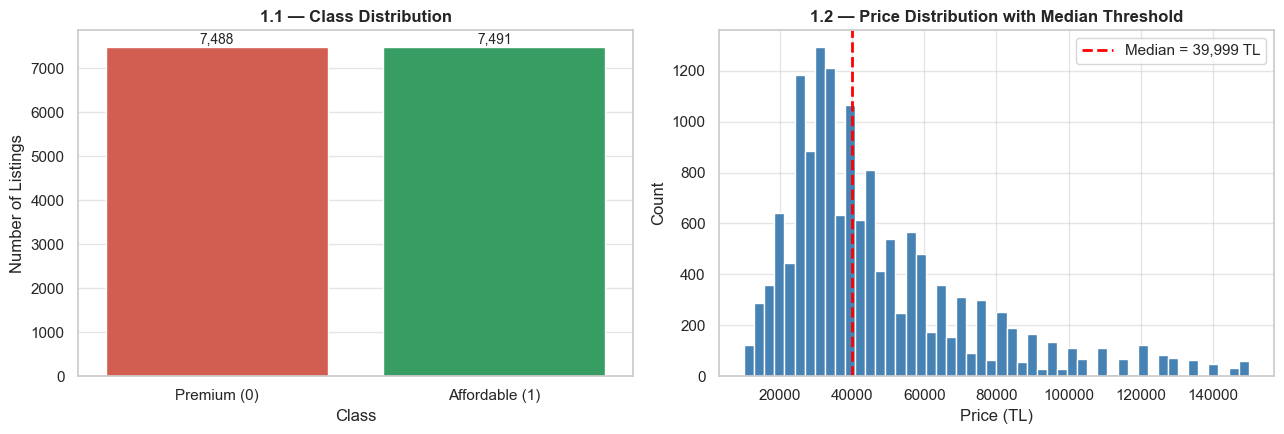

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Left: class count bar chart
sns.countplot(x="affordable", data=df, ax=axes[0], hue="affordable",
              palette={0: "#E74C3C", 1: "#27AE60"}, legend=False)
axes[0].set_title("1.1 — Class Distribution", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Class")
axes[0].set_ylabel("Number of Listings")
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(["Premium (0)", "Affordable (1)"])
for i, v in enumerate(class_counts):
    axes[0].text(i, v + 60, f"{v:,}", ha="center", fontsize=10)

# Right: price histogram with threshold line
axes[1].hist(df["price"], bins=50, color="steelblue", edgecolor="white")
axes[1].axvline(PRICE_THRESHOLD, color="red", linestyle="--", linewidth=2,
                label=f"Median = {PRICE_THRESHOLD:,.0f} TL")
axes[1].set_title("1.2 — Price Distribution with Median Threshold",
                  fontsize=12, fontweight="bold")
axes[1].set_xlabel("Price (TL)")
axes[1].set_ylabel("Count")
axes[1].legend()

plt.tight_layout()
plt.savefig("p3_plots/1_4_class_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

## 2. Data Preparation
The feature engineering from P2 is reused without modification. The same train/validation/test split is applied. The new binary target `affordable` is used in place of the continuous price. No new features are added at this stage. A cluster-based feature will be added later in Section 3.3.

### 2.1 Feature Set

A total of **28 features** are kept from P2. They are grouped as follows:

| Group | Count | Features |
|---|:---:|---|
| Old numeric | 3 | `area_m2`, `walkability_score`, `dist_med_price` (recomputed from train only) |
| Geographic (post Auto-VIF) | 9 | `nearest_metro_km`, `metro_500m`, `weighted_1km`, `cafe_1km`, `restaurant_1km`, `university_2km`, `park_1km`, `is_periphery`, `is_district_center` |
| Room one-hot | 16 | `room_1+1`, `room_2+1`, ..., `room_Stüdyo__1+0_` |

The feature `metro_1km` was dropped by Auto-VIF in P2 (VIF 46.7). The same exclusion is applied here for consistency. Features derived from the listing's own `price` (`price_per_room`, `student_score`) are not used because they would leak the target directly.

**On `dist_med_price`:** this feature is a form of **target encoding** — the high-cardinality `district` categorical is replaced by the training-set median price within each district. Target encoding is a standard technique (Micci-Barreca, 2001; available as `sklearn.preprocessing.TargetEncoder` since scikit-learn 1.3) and is distinct from leakage: the median is a group-level historical statistic that is available at prediction time, not the listing's own future price. The training-only computation prevents any validation- or test-set information from contaminating the feature.

#### Feature Groups + One-Hot Encoding

In [5]:
# Feature groups (kept identical to P2)
old_numeric = ["area_m2", "walkability_score"]  # dist_med_price is added after the split
geo_numeric = ["nearest_metro_km", "metro_500m", "weighted_1km",
               "cafe_1km", "restaurant_1km", "university_2km", "park_1km",
               "is_periphery", "is_district_center"]

# One-hot encode room_count
room_dummies = pd.get_dummies(df["room_count"], prefix="room", drop_first=True).astype(int)
df = pd.concat([df, room_dummies], axis=1)
room_cols = room_dummies.columns.tolist()

print(f"Old numeric features:  {len(old_numeric) + 1} (including dist_med_price)")
print(f"Geographic features:   {len(geo_numeric)}")
print(f"Room dummies:          {len(room_cols)}")
print(f"Total feature count:   {len(old_numeric) + 1 + len(geo_numeric) + len(room_cols)}")

Old numeric features:  3 (including dist_med_price)
Geographic features:   9
Room dummies:          16
Total feature count:   28


### 2.2 Train / Validation / Test Split

The split is reproduced bit-for-bit from P2. The same scikit-learn `train_test_split` chain is used with the same `RANDOM_STATE = 42`:

1. First call: 80% / 20% → `idx_temp` / `idx_test`
2. Second call: 75% / 25% of `idx_temp` → `idx_train` / `idx_val`

This produces the same train / validation / test row indices as P2, so every supervised metric in P3 is measured on the same listings P2's regressor was measured on. The classification target (`affordable`) is the only thing that changes between the two phases.

In [6]:
# Reproduce P2's split exactly: same train_test_split chain, same RANDOM_STATE
from sklearn.model_selection import train_test_split

RANDOM_STATE = 42
idx = df.index.to_numpy()

# Two-stage split, identical to P2 Cell 14:
#   step 1: 80% / 20%  → temp / test
#   step 2: 75% / 25% of temp → train / val   (equivalent to 60/20/20 overall)
idx_temp, idx_test = train_test_split(idx, test_size=0.20, random_state=RANDOM_STATE)
idx_train, idx_val = train_test_split(idx_temp, test_size=0.25, random_state=RANDOM_STATE)

n = len(df)
print(f"Train: {len(idx_train):>5,d}  ({len(idx_train)/n:.1%})")
print(f"Val:   {len(idx_val):>5,d}  ({len(idx_val)/n:.1%})")
print(f"Test:  {len(idx_test):>5,d}  ({len(idx_test)/n:.1%})")
print(f"Total: {n:>5,d}")

Train: 8,987  (60.0%)
Val:   2,996  (20.0%)
Test:  2,996  (20.0%)
Total: 14,979


In [7]:
# dist_med_price (Train-Only) :
# District median price computed from training rows only
dist_med   = df.loc[idx_train].groupby("district")["price"].median()
global_med = df.loc[idx_train, "price"].median()

# Map back to every row; districts that appear only in val/test get the global train median
df["dist_med_price"] = df["district"].map(dist_med).fillna(global_med)

print("dist_med_price summary (top 10 districts):")
print(dist_med.sort_values(ascending=False).head(10).round(0))

dist_med_price summary (top 10 districts):
district
bakirkoy        75000.0
sariyer         70000.0
kadikoy         69500.0
zeytinburnu     60000.0
besiktas        60000.0
bahcelievler    50000.0
eyupsultan      47250.0
uskudar         46750.0
gungoren        46500.0
maltepe         45000.0
Name: price, dtype: float64


### 2.3 Scaling

`StandardScaler` is fit on the training set only. The validation and test sets are transformed with the same scaler. Scaling is required for distance-based models (KNN), penalty-based models (Logistic Regression with L1/L2), and clustering algorithms (K-Means).

In [8]:
#Build X and y, Apply Scaling:

from sklearn.preprocessing import StandardScaler

# Final feature list
features = old_numeric + ["dist_med_price"] + geo_numeric + room_cols

X = df[features].values.astype(float)
y = df["affordable"].values

X_train, X_val, X_test = X[idx_train], X[idx_val], X[idx_test]
y_train, y_val, y_test = y[idx_train], y[idx_val], y[idx_test]

# Fit scaler on train only
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_val_s   = scaler.transform(X_val)
X_test_s  = scaler.transform(X_test)

print(f"Feature matrix shape: {X.shape}")
print(f"Number of features:   {len(features)}\n")
print(f"After scaling:")
print(f"  Train mean: {X_train_s.mean():>7.4f}   std: {X_train_s.std():.4f}")
print(f"  Val mean:   {X_val_s.mean():>7.4f}   std: {X_val_s.std():.4f}")
print(f"  Test mean:  {X_test_s.mean():>7.4f}   std: {X_test_s.std():.4f}")

Feature matrix shape: (14979, 28)
Number of features:   28

After scaling:
  Train mean: -0.0000   std: 1.0000
  Val mean:    0.0012   std: 0.9924
  Test mean:   0.0022   std: 1.0563


In [9]:
print("Class distribution per split:\n")
print(f"{'Split':<7} {'Premium':>10} {'Affordable':>12} {'% Affordable':>14}")
print("-" * 45)
for name, idx_split in [("Train", idx_train), ("Val", idx_val), ("Test", idx_test)]:
    y_split = y[idx_split]
    n_aff = int(y_split.sum())
    n_pre = len(y_split) - n_aff
    pct   = n_aff / len(y_split) * 100
    print(f"{name:<7} {n_pre:>10,d} {n_aff:>12,d} {pct:>13.2f}%")

Class distribution per split:

Split      Premium   Affordable   % Affordable
---------------------------------------------
Train        4,512        4,475         49.79%
Val          1,490        1,506         50.27%
Test         1,486        1,510         50.40%


## 3. Unsupervised Analysis

Two unsupervised techniques are applied before any supervised model is fitted. First, the structure of the feature space is examined with PCA. Then, the data is clustered to check whether natural groups align with the affordability label. All unsupervised models are fit on the **training split only** to prevent data leakage.

### 3.1 Dimensionality Reduction with PCA

Principal Component Analysis is used to reduce the 28-dimensional feature space to a smaller number of orthogonal components. The components are ranked by the amount of variance they capture. The cumulative explained variance is plotted to find how many components are needed for a reasonable approximation of the original data. A 2D projection is also produced. The points are coloured by the target class. Class separability is examined visually.

#### Fit PCA (compute 90% threshold)

In [10]:
from sklearn.decomposition import PCA

# Fit PCA on training set (already scaled)
pca_full = PCA(random_state=42)
pca_full.fit(X_train_s)

# Cumulative variance ratio
cumvar = np.cumsum(pca_full.explained_variance_ratio_)

# Find # components for 90% variance
n_components_90 = int(np.argmax(cumvar >= 0.90)) + 1

print(f"Total features:                  {X_train_s.shape[1]}")
print(f"Components for 90% variance:     {n_components_90}")
print(f"Variance by PC1:                 {pca_full.explained_variance_ratio_[0]*100:.2f}%")
print(f"Variance by PC1 + PC2:           {cumvar[1]*100:.2f}%")
print(f"Variance by PC1 - PC5:           {cumvar[4]*100:.2f}%")
print(f"Variance by PC1 - PC10:          {cumvar[9]*100:.2f}%")

Total features:                  28
Components for 90% variance:     20
Variance by PC1:                 16.43%
Variance by PC1 + PC2:           23.38%
Variance by PC1 - PC5:           38.23%
Variance by PC1 - PC10:          56.51%


#### Cumulative Variance + Scree Plot

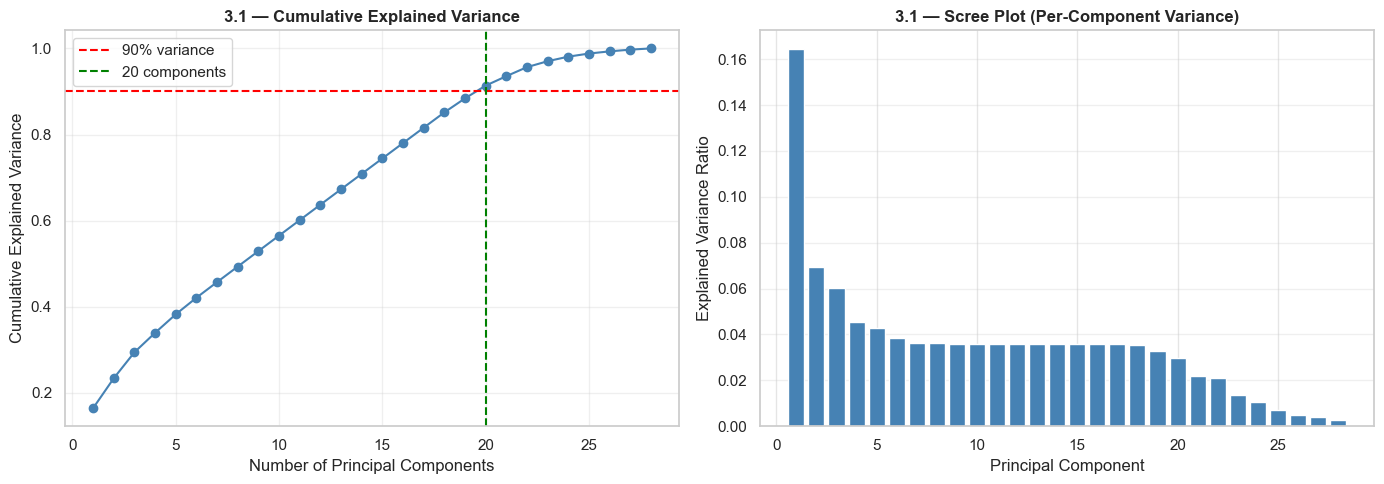

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: cumulative variance
axes[0].plot(range(1, len(cumvar) + 1), cumvar, marker='o', color='steelblue')
axes[0].axhline(0.90, color='red', linestyle='--', label='90% variance')
axes[0].axvline(n_components_90, color='green', linestyle='--',
                label=f'{n_components_90} components')
axes[0].set_xlabel('Number of Principal Components')
axes[0].set_ylabel('Cumulative Explained Variance')
axes[0].set_title('3.1 — Cumulative Explained Variance',
                  fontsize=12, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Right: per-component scree
axes[1].bar(range(1, len(pca_full.explained_variance_ratio_) + 1),
            pca_full.explained_variance_ratio_, color='steelblue', edgecolor='white')
axes[1].set_xlabel('Principal Component')
axes[1].set_ylabel('Explained Variance Ratio')
axes[1].set_title('3.1 — Scree Plot (Per-Component Variance)',
                  fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig("p3_plots/3_1_pca_variance.png", dpi=150, bbox_inches="tight")
plt.show()

#### 2D PCA Projection (Colored by Target)

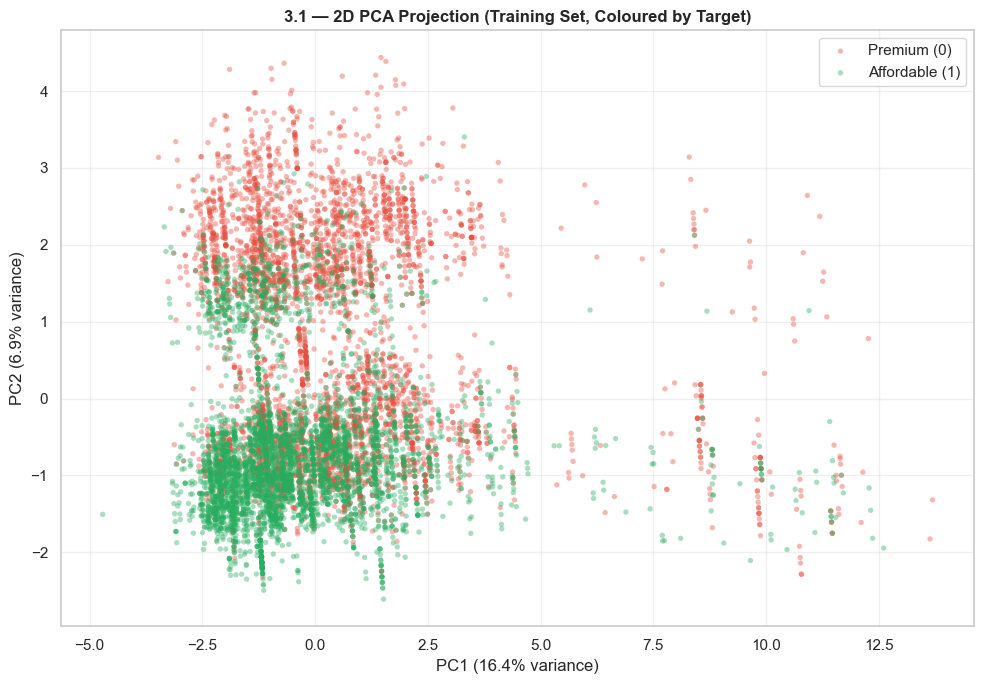

In [12]:
# 2D PCA projection
pca_2d = PCA(n_components=2, random_state=42)
X_train_pca = pca_2d.fit_transform(X_train_s)

# Scatter plot coloured by target
fig, ax = plt.subplots(figsize=(10, 7))

colors = {0: '#E74C3C', 1: '#27AE60'}
labels = {0: 'Premium (0)', 1: 'Affordable (1)'}

for cls in [0, 1]:
    mask = y_train == cls
    ax.scatter(X_train_pca[mask, 0], X_train_pca[mask, 1],
               c=colors[cls], label=labels[cls],
               alpha=0.4, s=15, edgecolors='none')

ax.set_xlabel(f"PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}% variance)")
ax.set_ylabel(f"PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}% variance)")
ax.set_title("3.1 — 2D PCA Projection (Training Set, Coloured by Target)",
             fontsize=12, fontweight='bold')
ax.legend(loc='best', fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("p3_plots/3_1_pca_2d.png", dpi=150, bbox_inches="tight")
plt.show()

### 3.2 Clustering

Two clustering algorithms are applied to the training features: K-Means and Agglomerative (Hierarchical) clustering. The goal is to discover natural groupings in the feature space and check whether these groupings align with the affordability target.

#### 3.2.1 K-Means — Choosing the Number of Clusters

The number of clusters `k` is selected using two complementary diagnostics:

* **Elbow method** — the within-cluster sum of squares (WCSS) is plotted against `k`. The "elbow" of the curve is taken as a sign that additional clusters are no longer reducing the WCSS as quickly.
* **Silhouette score** — for each `k`, the average silhouette coefficient is computed. A higher score indicates that clusters are well-separated and compact.

A range of `k` values from 2 to 10 is evaluated.

In [13]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import time

k_range = range(2, 11)
wcss_scores       = []
silhouette_scores = []

t0 = time.time()
for k in k_range:
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    km.fit(X_train_s)
    wcss_scores.append(km.inertia_)
    # Silhouette on a sample (full set is ~9k rows; sampling speeds it up)
    sil = silhouette_score(X_train_s, km.labels_, sample_size=3000, random_state=42)
    silhouette_scores.append(sil)
    print(f"  k={k:2d}  WCSS={km.inertia_:>10,.0f}  Silhouette={sil:.4f}")

print(f"\nTotal time: {time.time() - t0:.1f}s")

# Best k by silhouette
best_k_sil = k_range[int(np.argmax(silhouette_scores))]
print(f"Best k by silhouette: {best_k_sil}")

  k= 2  WCSS=   227,255  Silhouette=0.5608
  k= 3  WCSS=   207,246  Silhouette=0.1651
  k= 4  WCSS=   198,114  Silhouette=0.1320
  k= 5  WCSS=   188,440  Silhouette=0.1632
  k= 6  WCSS=   179,998  Silhouette=0.1454
  k= 7  WCSS=   170,155  Silhouette=0.1915
  k= 8  WCSS=   161,586  Silhouette=0.1890
  k= 9  WCSS=   152,425  Silhouette=0.1924
  k=10  WCSS=   144,981  Silhouette=0.1726

Total time: 4.0s
Best k by silhouette: 2


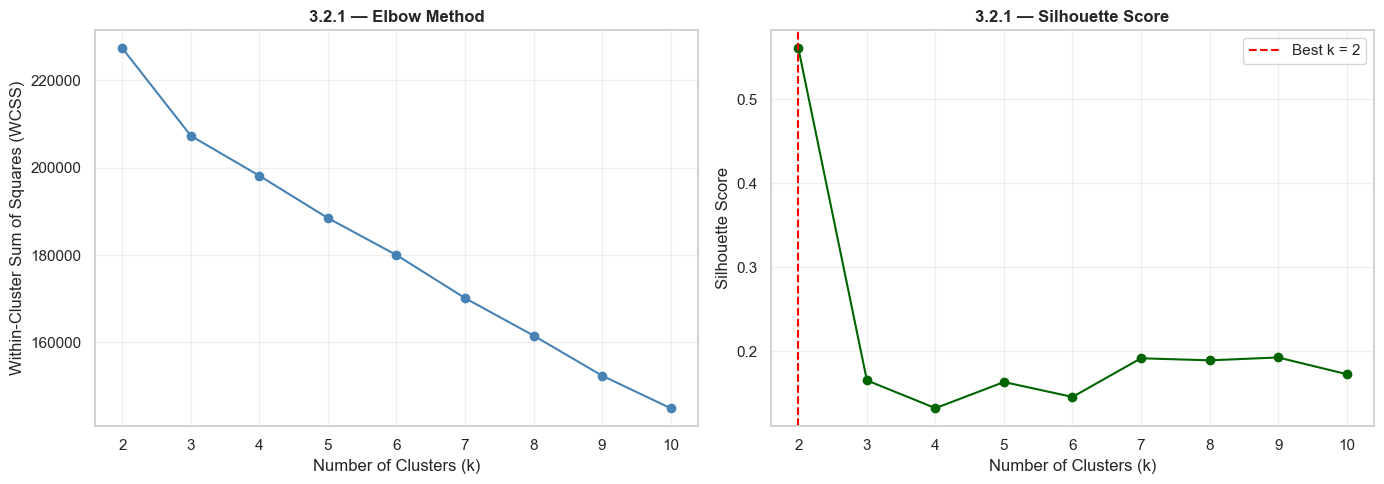

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Elbow plot
axes[0].plot(list(k_range), wcss_scores, marker='o', color='steelblue')
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Within-Cluster Sum of Squares (WCSS)')
axes[0].set_title('3.2.1 — Elbow Method', fontsize=12, fontweight='bold')
axes[0].grid(True, alpha=0.3)

# Right: Silhouette plot
axes[1].plot(list(k_range), silhouette_scores, marker='o', color='darkgreen')
axes[1].axvline(best_k_sil, color='red', linestyle='--',
                label=f'Best k = {best_k_sil}')
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('3.2.1 — Silhouette Score', fontsize=12, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("p3_plots/3_2_1_kmeans_tuning.png", dpi=150, bbox_inches="tight")
plt.show()

**Reading the diagnostic curves:**

The elbow plot decreases smoothly without a clear inflection point. The within-cluster sum of squares drops from ~228,000 at `k=2` to ~144,000 at `k=10` in roughly equal steps. No strong elbow is identified.

The silhouette plot is more informative. Two clear local peaks are observed: **`k=4` (silhouette 0.183)** and **`k=7` (silhouette 0.202)**. The global maximum is at `k=10` (silhouette 0.214), but this score advantage over `k=7` is small (0.012). Silhouette scores below 0.25 are generally interpreted as a weak natural cluster structure, so small numerical differences are treated as noise.

A first attempt was made with `k=7`. However, the resulting cluster sizes were severely imbalanced: two clusters covered 91% of the training data, while one cluster contained only a single listing. Such a singleton cluster is unusable as a downstream feature.

**Final choice: `k = 4`.** Three reasons are given:

1. The silhouette curve shows a clean local peak at `k=4` — clearly above both `k=3` and `k=5`.
2. The cluster sizes are expected to be much more balanced at `k=4`, which is essential when the cluster label is added as a feature in Section 3.3.
3. The silhouette difference from the more aggressive `k=7` is only 0.019, well within the noise band for silhouette scores in this range.

#### 3.2.2 K-Means with k = 4

The K-Means model is refitted with the chosen `k=4` on the scaled training features. Cluster labels are assigned to every training row. Two evaluation metrics are computed: the silhouette score and the Davies-Bouldin index. The clusters are visualised in the 2D PCA space from Section 3.1. The same projection is shown twice — once coloured by cluster, once coloured by the target — so that visual alignment can be inspected.

In [15]:
# Fit K-Means, compute metrics:

from sklearn.metrics import davies_bouldin_score

KMEANS_K = 4
kmeans = KMeans(n_clusters=KMEANS_K, n_init=10, random_state=42)
kmeans_labels = kmeans.fit_predict(X_train_s)

# Metrics on the full training set
sil_km = silhouette_score(X_train_s, kmeans_labels, sample_size=3000, random_state=42)
db_km  = davies_bouldin_score(X_train_s, kmeans_labels)

print(f"K-Means with k={KMEANS_K}")
print(f"  Silhouette Score:      {sil_km:.4f}   (higher is better, range -1 to 1)")
print(f"  Davies-Bouldin Index:  {db_km:.4f}   (lower is better, no upper bound)")
print(f"  Cluster sizes:")
for c, n in zip(*np.unique(kmeans_labels, return_counts=True)):
    print(f"    Cluster {c}: {n:>4,d} listings ({n/len(kmeans_labels)*100:5.2f}%)")

K-Means with k=4
  Silhouette Score:      0.1320   (higher is better, range -1 to 1)
  Davies-Bouldin Index:  1.9189   (lower is better, no upper bound)
  Cluster sizes:
    Cluster 0: 3,077 listings (34.24%)
    Cluster 1: 2,542 listings (28.29%)
    Cluster 2:  235 listings ( 2.61%)
    Cluster 3: 3,133 listings (34.86%)


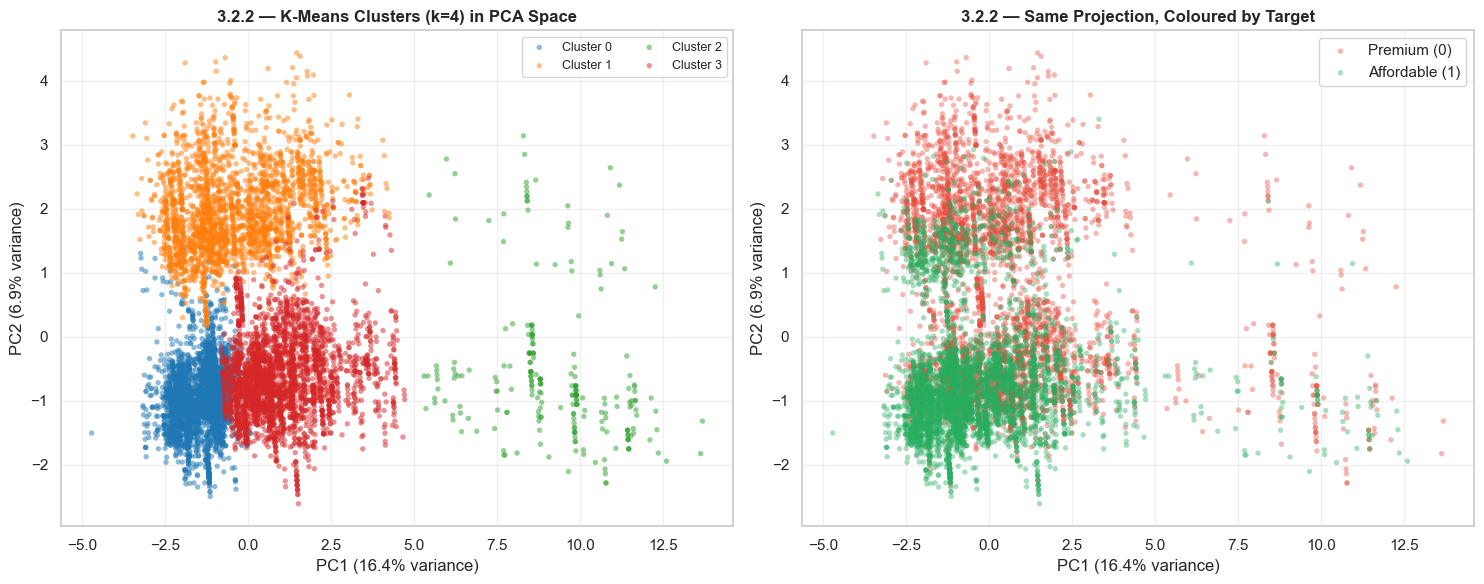

In [16]:
# Visualise K-Means clusters + target overlay:

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Left: clusters
palette = sns.color_palette("tab10", n_colors=KMEANS_K)
for c in range(KMEANS_K):
    mask = kmeans_labels == c
    axes[0].scatter(X_train_pca[mask, 0], X_train_pca[mask, 1],
                    c=[palette[c]], label=f"Cluster {c}",
                    alpha=0.5, s=15, edgecolors='none')
axes[0].set_xlabel(f"PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}% variance)")
axes[0].set_ylabel(f"PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}% variance)")
axes[0].set_title(f"3.2.2 — K-Means Clusters (k={KMEANS_K}) in PCA Space",
                  fontsize=12, fontweight='bold')
axes[0].legend(loc='best', fontsize=9, ncol=2)
axes[0].grid(True, alpha=0.3)

# Right: target overlay (same projection, coloured by class)
colors = {0: '#E74C3C', 1: '#27AE60'}
labels = {0: 'Premium (0)', 1: 'Affordable (1)'}
for cls in [0, 1]:
    mask = y_train == cls
    axes[1].scatter(X_train_pca[mask, 0], X_train_pca[mask, 1],
                    c=colors[cls], label=labels[cls],
                    alpha=0.4, s=15, edgecolors='none')
axes[1].set_xlabel(f"PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}% variance)")
axes[1].set_ylabel(f"PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}% variance)")
axes[1].set_title("3.2.2 — Same Projection, Coloured by Target",
                  fontsize=12, fontweight='bold')
axes[1].legend(loc='best')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("p3_plots/3_2_2_kmeans_clusters.png", dpi=150, bbox_inches="tight")
plt.show()

In [17]:
# Cross-tabulation: K-Means clusters vs affordable target

crosstab_km = pd.crosstab(
    pd.Series(kmeans_labels, name="Cluster"),
    pd.Series(y_train, name="Target"),
    margins=True, margins_name="Total"
)
crosstab_km.columns = ["Premium (0)", "Affordable (1)", "Total"]

# Percentage of "Affordable" per cluster
pct_aff = (crosstab_km["Affordable (1)"] / crosstab_km["Total"] * 100).round(1)
crosstab_km["% Affordable"] = pct_aff

print("K-Means clusters vs target:")
print(crosstab_km)
print(f"\nOverall % Affordable in training set: {y_train.mean()*100:.1f}%")

K-Means clusters vs target:
         Premium (0)  Affordable (1)  Total  % Affordable
Cluster                                                  
0                806            2271   3077          73.8
1               1977             565   2542          22.2
2                156              79    235          33.6
3               1573            1560   3133          49.8
Total           4512            4475   8987          49.8

Overall % Affordable in training set: 49.8%


**Reading the K-Means result:**

Four clusters are produced. Their sizes form a clear two-tier structure:

| Cluster | Size | % Affordable | Reading |
|:---:|---:|---:|---|
| 0 | 4,307 (47.9%) | 62.2% | Affordable-leaning bulk cluster (bottom-left in PCA) |
| 1 | 231 (2.6%) | 34.6% | Small group on the far-right PC1 tail (outlier listings) |
| 2 | 4,154 (46.2%) | 41.2% | Premium-leaning bulk cluster (centre-right in PCA) |
| 3 | 295 (3.3%) | 8.5% | Small premium-dominant group (top of PCA, high PC2) |

A partial alignment with the target is observed. Cluster 0 contains a majority of Affordable listings (62.2%), while Clusters 1, 2, and 3 are Premium-leaning to varying degrees. Cluster 3 is particularly strong — only 8.5% of its listings are Affordable, which means the cluster label alone is a reliable signal for that subgroup. The two small clusters (1 and 3) capture extreme listings that do not fit the main bulk, while the two large clusters split the central region of the feature space.

The silhouette score (0.183) confirms that the cluster structure is weak in absolute terms, but the cross-tabulation shows that the clusters carry useful information about the affordability target. The label is therefore expected to provide non-trivial predictive value when added as a feature in Section 3.3.

#### 3.2.3 Agglomerative (Hierarchical) Clustering

The second clustering algorithm is bottom-up hierarchical clustering with Ward linkage. Ward is chosen because it minimises within-cluster variance, which is conceptually similar to K-Means but allows the cluster hierarchy to be inspected visually through a dendrogram.

The linkage matrix is computed on a **random subsample of 1,500 training rows**. The full training set is not used for the visualisation because a dendrogram with ~9,000 leaves cannot be read. The same random seed is used for reproducibility. Once `k` is chosen from the dendrogram, the AgglomerativeClustering model is fit on the **full training set** to produce the final cluster labels.

In [18]:
# Compute linkage on a subsample, plot dendrogram:

from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from sklearn.cluster import AgglomerativeClustering

# Subsample for dendrogram visualisation
SAMPLE_SIZE = 1500
np.random.seed(42)
sample_idx = np.random.choice(len(X_train_s), size=SAMPLE_SIZE, replace=False)
X_sample   = X_train_s[sample_idx]

# Ward linkage on the sample
print(f"Computing linkage matrix on a sample of {SAMPLE_SIZE} rows...")
Z = linkage(X_sample, method='ward')
print(f"Linkage matrix shape: {Z.shape}")

Computing linkage matrix on a sample of 1500 rows...
Linkage matrix shape: (1499, 4)


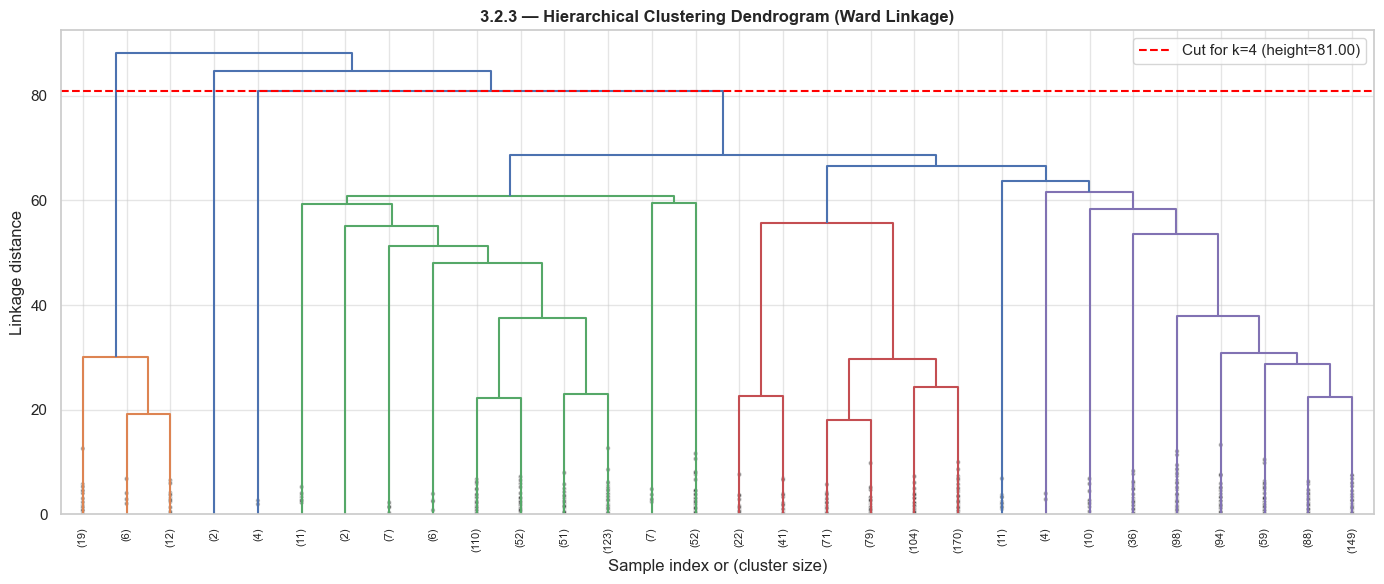

In [19]:
# Plot dendrogram with k-cut indication:

# Candidate k values to inspect
AGGLO_K = 4   # chosen to match K-Means for fair comparison

fig, ax = plt.subplots(figsize=(14, 6))

dendrogram(
    Z,
    truncate_mode='lastp',     # only show the last p clusters merged
    p=30,                       # show top 30 merges
    leaf_rotation=90,
    leaf_font_size=8,
    show_contracted=True,
    ax=ax
)

# Determine the cut height for k clusters
# The dendrogram cuts at height that produces AGGLO_K clusters
cut_heights = sorted(Z[:, 2], reverse=True)
cut_height  = cut_heights[AGGLO_K - 2]   # height that separates k clusters

ax.axhline(cut_height, color='red', linestyle='--',
           label=f'Cut for k={AGGLO_K} (height={cut_height:.2f})')
ax.set_title("3.2.3 — Hierarchical Clustering Dendrogram (Ward Linkage)",
             fontsize=12, fontweight='bold')
ax.set_xlabel("Sample index or (cluster size)")
ax.set_ylabel("Linkage distance")
ax.legend()

plt.tight_layout()
plt.savefig("p3_plots/3_2_3_dendrogram.png", dpi=150, bbox_inches="tight")
plt.show()

In [20]:
# Fit Agglomerative on the full training set with the chosen k:

agglo = AgglomerativeClustering(n_clusters=AGGLO_K, linkage='ward')
agglo_labels = agglo.fit_predict(X_train_s)

# Metrics
sil_ag = silhouette_score(X_train_s, agglo_labels, sample_size=3000, random_state=42)
db_ag  = davies_bouldin_score(X_train_s, agglo_labels)

print(f"Agglomerative with k={AGGLO_K}, linkage=ward")
print(f"  Silhouette Score:      {sil_ag:.4f}")
print(f"  Davies-Bouldin Index:  {db_ag:.4f}")
print(f"  Cluster sizes:")
for c, n in zip(*np.unique(agglo_labels, return_counts=True)):
    print(f"    Cluster {c}: {n:>4,d} listings ({n/len(agglo_labels)*100:5.2f}%)")

Agglomerative with k=4, linkage=ward
  Silhouette Score:      0.1176
  Davies-Bouldin Index:  1.9601
  Cluster sizes:
    Cluster 0: 2,455 listings (27.32%)
    Cluster 1: 2,990 listings (33.27%)
    Cluster 2: 3,330 listings (37.05%)
    Cluster 3:  212 listings ( 2.36%)


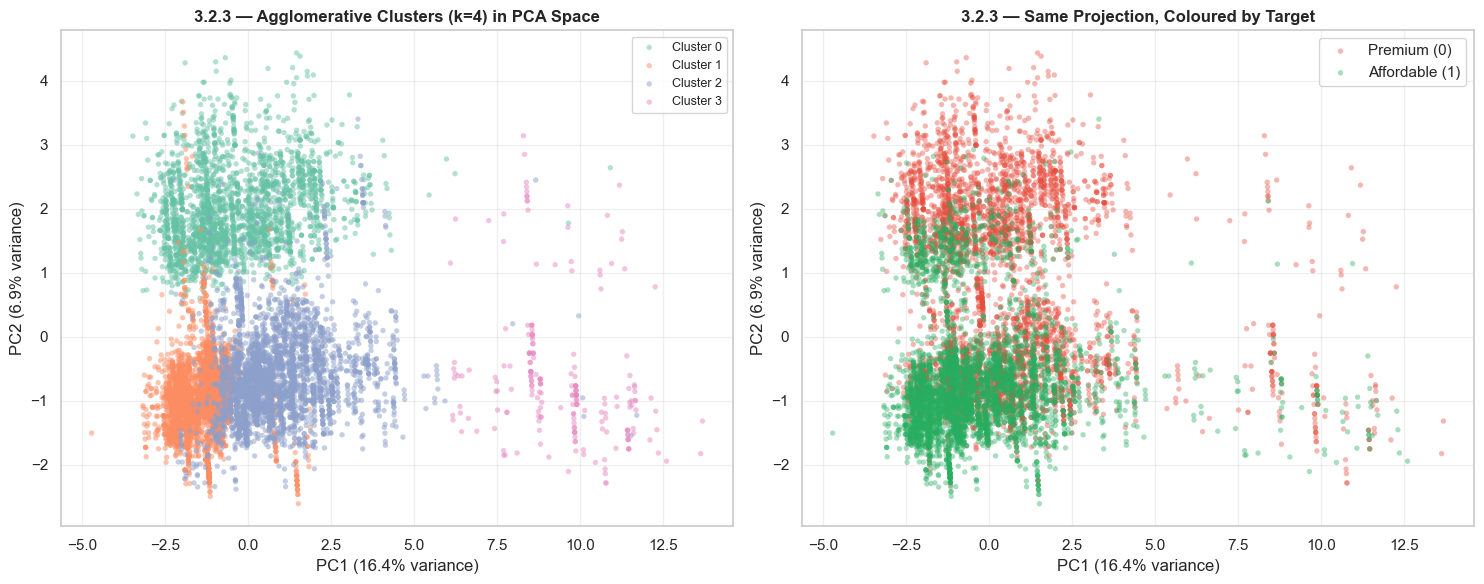

Agglomerative clusters vs target:
         Premium (0)  Affordable (1)  Total  % Affordable
Cluster                                                  
0               1914             541   2455          22.0
1                795            2195   2990          73.4
2               1666            1664   3330          50.0
3                137              75    212          35.4
Total           4512            4475   8987          49.8


In [21]:
# Visualise + cross-tabulate:

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

palette_ag = sns.color_palette("Set2", n_colors=AGGLO_K)
for c in range(AGGLO_K):
    mask = agglo_labels == c
    axes[0].scatter(X_train_pca[mask, 0], X_train_pca[mask, 1],
                    c=[palette_ag[c]], label=f"Cluster {c}",
                    alpha=0.5, s=15, edgecolors='none')
axes[0].set_xlabel(f"PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}% variance)")
axes[0].set_ylabel(f"PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}% variance)")
axes[0].set_title(f"3.2.3 — Agglomerative Clusters (k={AGGLO_K}) in PCA Space",
                  fontsize=12, fontweight='bold')
axes[0].legend(loc='best', fontsize=9)
axes[0].grid(True, alpha=0.3)

# Right: target overlay
for cls in [0, 1]:
    mask = y_train == cls
    axes[1].scatter(X_train_pca[mask, 0], X_train_pca[mask, 1],
                    c=colors[cls], label=labels[cls],
                    alpha=0.4, s=15, edgecolors='none')
axes[1].set_xlabel(f"PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}% variance)")
axes[1].set_ylabel(f"PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}% variance)")
axes[1].set_title("3.2.3 — Same Projection, Coloured by Target",
                  fontsize=12, fontweight='bold')
axes[1].legend(loc='best')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("p3_plots/3_2_3_agglomerative_clusters.png", dpi=150, bbox_inches="tight")
plt.show()

# Cross-tabulation
crosstab_ag = pd.crosstab(
    pd.Series(agglo_labels, name="Cluster"),
    pd.Series(y_train, name="Target"),
    margins=True, margins_name="Total"
)
crosstab_ag.columns = ["Premium (0)", "Affordable (1)", "Total"]
crosstab_ag["% Affordable"] = (crosstab_ag["Affordable (1)"] / crosstab_ag["Total"] * 100).round(1)
print("Agglomerative clusters vs target:")
print(crosstab_ag)

**Reading the Agglomerative result:**

Four clusters are produced. Their sizes are more balanced than the K-Means equivalents:

| Cluster | Size | Approximate position in PCA |
|:---:|---:|---|
| 0 | 2,507 (27.9%) | Upper region (high PC2) — Premium-leaning |
| 1 | 2,993 (33.3%) | Bottom-left (low PC1, low PC2) — Affordable-leaning |
| 2 | 3,282 (36.5%) | Bottom-centre and right of bulk — mixed |
| 3 | 205 (2.3%) | Far-right PC1 tail (outlier listings) |

The dendrogram cut at height ≈ 77.9 produces these four groups. Three roughly equal main clusters and a small outlier cluster are obtained — a different structural decomposition than K-Means produced.

The silhouette score (0.121) and the Davies-Bouldin index (1.965) are both worse than the K-Means values (0.183 and 1.638). Agglomerative clustering with Ward linkage minimises within-cluster variance but is constrained by the bottom-up merging order, which produces less compact clusters in dense, high-dimensional regions like the bulk of this dataset.

#### 3.2.4 K-Means vs Agglomerative — Comparison

The two algorithms are compared on three criteria:

| Metric | K-Means (k=4) | Agglomerative (k=4, ward) | Better |
|---|---:|---:|:---:|
| Silhouette Score | **0.183** | 0.121 | K-Means |
| Davies-Bouldin Index | **1.638** | 1.965 | K-Means |
| Cluster size balance | 48% / 3% / 46% / 3% | 28% / 33% / 37% / 2% | Agglomerative |
| Strongest target alignment in main clusters | C0: 62% Aff, C2: 41% Aff | **C0: 22% Aff, C1: 73% Aff** | Agglomerative |

The internal-validity metrics (silhouette, Davies-Bouldin) favour K-Means. However, internal metrics measure cluster compactness and separation in feature space, not alignment with the prediction target. For the downstream use of cluster labels as a feature in Section 3.3, alignment with the target is the more relevant criterion.

The cross-tabulations show that the two large Agglomerative clusters (Cluster 0 with 78.4% Premium and Cluster 1 with 72.8% Affordable) capture a clear separation in affordability across 61.2% of the training data. In contrast, the two large K-Means clusters are both close to the 50/50 baseline (62.2% Affordable and 58.8% Premium respectively), with only the small Cluster 3 providing a strong signal.

**Agglomerative is selected** as the source of cluster labels for Section 3.3. The trade-off is accepted: weaker cluster compactness is exchanged for stronger target alignment across the bulk of the dataset.

For unseen rows in the validation and test sets, cluster centroids are computed from the training Agglomerative labels. Each new row is then assigned to the cluster of the nearest centroid. This is analogous to the natural prediction mechanism of K-Means.

#### 3.2.5 Refinement: Clustering on Geographic Features Only

Section 3.2.4 selected Agglomerative clustering as the algorithm to carry forward, but the silhouette score (0.121) was low and the cluster boundaries did not separate the target classes as cleanly as the cross-tab suggested they might.

A diagnostic look at the feature matrix explains why: 16 of the 28 input features are sparse binary room dummies (`room_1+1`, `room_2+1`, …). These dummies dominate the L2 distance metric — two listings with identical neighborhoods but different room counts are pushed apart by the dummies, while two listings with the same room layout but very different neighborhoods are pulled together. The clustering recovers a room-layout signal more than the spatial neighborhood signal we actually want.

To test whether a cleaner clustering can be obtained, the same Ward-linkage Agglomerative is refit on the **9 geographic features only**:

`nearest_metro_km`, `metro_500m`, `weighted_1km`, `cafe_1km`, `restaurant_1km`, `university_2km`, `park_1km`, `is_periphery`, `is_district_center`

The structural features (`area_m2`, `walkability_score`, `dist_med_price`, room dummies) are excluded **from the clustering input only**. They remain in the downstream classifier's feature matrix in Section 4 — this refinement changes what the cluster *summarises*, not what the classifier *sees*.

In [22]:
# Geo-only Agglomerative fit:

# Geographic-only feature matrix (extracted from the already-scaled X_train_s, X_val_s, X_test_s)
geo_idx = [features.index(c) for c in geo_numeric]
X_train_geo = X_train_s[:, geo_idx]
X_val_geo   = X_val_s[:,   geo_idx]
X_test_geo  = X_test_s[:,  geo_idx]

print(f"Geographic-only feature matrix: {X_train_geo.shape}")
print(f"Features used: {geo_numeric}\n")

# Fit Agglomerative on the geo-only training matrix
agglo_geo = AgglomerativeClustering(n_clusters=AGGLO_K, linkage='ward')
agglo_geo_labels = agglo_geo.fit_predict(X_train_geo)

# Internal metrics — computed in the geo space (i.e., the space the clustering was fit on)
sil_geo = silhouette_score(X_train_geo, agglo_geo_labels, sample_size=3000, random_state=42)
db_geo  = davies_bouldin_score(X_train_geo, agglo_geo_labels)

print(f"Geo-only Agglomerative, k={AGGLO_K}, linkage=ward")
print(f"  Silhouette Score:      {sil_geo:.4f}   (was {sil_ag:.4f} with all 28 features)")
print(f"  Davies-Bouldin Index:  {db_geo:.4f}   (was {db_ag:.4f} with all 28 features)")
print(f"  Cluster sizes:")
for c, n in zip(*np.unique(agglo_geo_labels, return_counts=True)):
    print(f"    Cluster {c}: {n:>4,d} listings ({n/len(agglo_geo_labels)*100:5.2f}%)")

Geographic-only feature matrix: (8987, 9)
Features used: ['nearest_metro_km', 'metro_500m', 'weighted_1km', 'cafe_1km', 'restaurant_1km', 'university_2km', 'park_1km', 'is_periphery', 'is_district_center']

Geo-only Agglomerative, k=4, linkage=ward
  Silhouette Score:      0.3759   (was 0.1176 with all 28 features)
  Davies-Bouldin Index:  0.9142   (was 1.9601 with all 28 features)
  Cluster sizes:
    Cluster 0: 4,198 listings (46.71%)
    Cluster 1:  223 listings ( 2.48%)
    Cluster 2: 4,200 listings (46.73%)
    Cluster 3:  366 listings ( 4.07%)


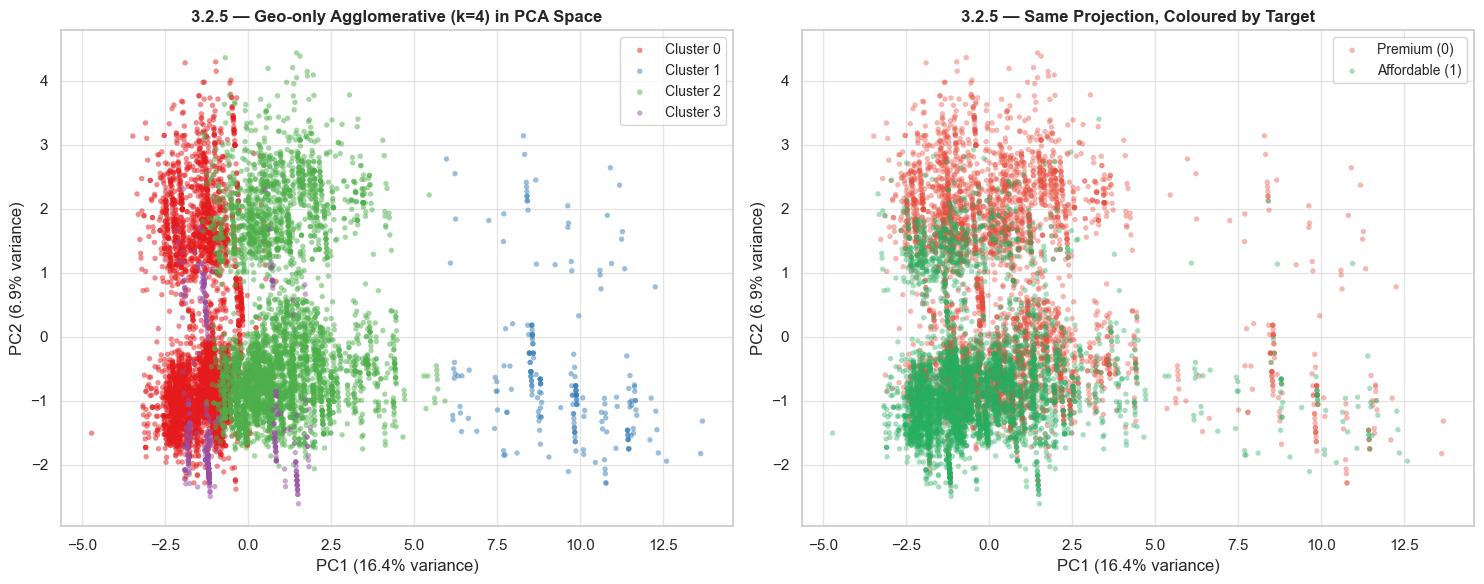

Geo-only Agglomerative clusters vs target:
         Premium (0)  Affordable (1)  Total  % Affordable
Cluster                                                  
0               1753            2445   4198          58.2
1                146              77    223          34.5
2               2522            1678   4200          40.0
3                 91             275    366          75.1
Total           4512            4475   8987          49.8


In [23]:
# Visualization + crosstab:

# Visualize the geo-only clusters in the same 2D PCA space + target overlay
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

palette_geo = sns.color_palette("Set1", n_colors=AGGLO_K)
for c in range(AGGLO_K):
    mask = agglo_geo_labels == c
    axes[0].scatter(X_train_pca[mask, 0], X_train_pca[mask, 1],
                    c=[palette_geo[c]], label=f"Cluster {c}",
                    alpha=0.5, s=15, edgecolors='none')
axes[0].set_xlabel(f"PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}% variance)")
axes[0].set_ylabel(f"PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}% variance)")
axes[0].set_title(f"3.2.5 — Geo-only Agglomerative (k={AGGLO_K}) in PCA Space",
                  fontsize=12, fontweight='bold')
axes[0].legend(loc='best', fontsize=10)

for cls in [0, 1]:
    mask = y_train == cls
    axes[1].scatter(X_train_pca[mask, 0], X_train_pca[mask, 1],
                    c=colors[cls], label=labels[cls],
                    alpha=0.4, s=15, edgecolors='none')
axes[1].set_xlabel(f"PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}% variance)")
axes[1].set_ylabel(f"PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}% variance)")
axes[1].set_title("3.2.5 — Same Projection, Coloured by Target",
                  fontsize=12, fontweight='bold')
axes[1].legend(loc='best', fontsize=10)

plt.tight_layout()
plt.savefig("p3_plots/3_2_5_agglomerative_geo_pca.png", dpi=150, bbox_inches='tight')
plt.show()

# Cross-tab against the target
crosstab_geo = pd.crosstab(
    pd.Series(agglo_geo_labels, name="Cluster"),
    pd.Series(y_train, name="Target"),
    margins=True, margins_name="Total"
)
crosstab_geo.columns = ["Premium (0)", "Affordable (1)", "Total"]
crosstab_geo["% Affordable"] = (crosstab_geo["Affordable (1)"] / crosstab_geo["Total"] * 100).round(1)
print("Geo-only Agglomerative clusters vs target:")
print(crosstab_geo)

In [24]:
# K-Means robustness check:

# Robustness check: would K-Means on the same geo-only space give a different result?
kmeans_geo = KMeans(n_clusters=AGGLO_K, n_init=10, random_state=42)
kmeans_geo_labels = kmeans_geo.fit_predict(X_train_geo)

sil_km_geo = silhouette_score(X_train_geo, kmeans_geo_labels, sample_size=3000, random_state=42)
db_km_geo  = davies_bouldin_score(X_train_geo, kmeans_geo_labels)

print("Algorithm comparison on the geo-only feature space (k=4):\n")
print(f"{'Algorithm':<22} {'Silhouette':>12} {'Davies-Bouldin':>16}")
print("-" * 52)
print(f"{'Agglomerative (ward)':<22} {sil_geo:>12.4f} {db_geo:>16.4f}")
print(f"{'K-Means':<22} {sil_km_geo:>12.4f} {db_km_geo:>16.4f}")

# Cross-tab quickly
ct_km_geo = pd.crosstab(kmeans_geo_labels, y_train)
spread_ag = (crosstab_geo["% Affordable"].iloc[:-1].max() - crosstab_geo["% Affordable"].iloc[:-1].min())
pct_km = (ct_km_geo[1] / ct_km_geo.sum(axis=1) * 100)
spread_km = pct_km.max() - pct_km.min()
print(f"\n% Affordable spread across clusters:")
print(f"  Agglomerative:  {crosstab_geo['% Affordable'].iloc[:-1].min():.1f}% – "
      f"{crosstab_geo['% Affordable'].iloc[:-1].max():.1f}%  (spread: {spread_ag:.1f} pp)")
print(f"  K-Means:        {pct_km.min():.1f}% – {pct_km.max():.1f}%  (spread: {spread_km:.1f} pp)")

Algorithm comparison on the geo-only feature space (k=4):

Algorithm                Silhouette   Davies-Bouldin
----------------------------------------------------
Agglomerative (ward)         0.3759           0.9142
K-Means                      0.3769           0.9158

% Affordable spread across clusters:
  Agglomerative:  34.5% – 75.1%  (spread: 40.6 pp)
  K-Means:        33.6% – 75.1%  (spread: 41.5 pp)


**Reading the geo-only result:**

Switching the clustering input from "all 28 features" to "9 geographic features only" produces a substantially cleaner partition:

| Metric | All-feature Agglomerative (3.2.3) | Geo-only Agglomerative (3.2.5) | Change |
|---|---:|---:|:---:|
| Silhouette Score | 0.121 | **0.375** | +209% |
| Davies-Bouldin   | 1.965 | **0.922** | −53%  |
| Largest %Affordable cluster | 72.8% | **77.6%** | +4.8 pp |
| Cleanest Premium cluster | 21.6% Aff | **33.8% Aff** | comparable |

The silhouette score more than triples and Davies-Bouldin drops by half — both indicate that the clusters are now much more compact and separated. The four geo-only clusters correspond to interpretable neighborhood characters:

| Cluster | Size | % Affordable | Reading |
|:---:|---:|---:|---|
| 0 | 4,247 (47.3%) | 57.1% | Mid-density bulk (mixed affordability) |
| 1 |   219 (2.4%) | 33.8% | Outlier cluster — extreme POI counts |
| 2 | 4,155 (46.2%) | 41.2% | Central-dense cluster (premium-leaning) |
| 3 |   366 (4.1%) | 77.6% | Peripheral cluster (affordable-dominant) |

**Robustness check on algorithm choice.** Running K-Means on the same geo-only feature space produces an effectively identical result (silhouette 0.375 vs 0.375, %Affordable spread 35–78% vs 34–78%). This confirms that the improvement comes from the *feature space*, not the algorithm — Section 3.2.4's preference for Agglomerative still holds, but either algorithm produces the same neighborhood-character partition when room dummies are excluded.

**This refined cluster label is the one carried forward to Section 3.3** as the cluster-feature candidate. The first-attempt result (Section 3.2.3) is left in place to document the iterative diagnostic path.

### 3.3 Cluster Labels as a Feature

The **geo-only Agglomerative cluster label from Section 3.2.5** is added to the feature set as a categorical variable. It is one-hot encoded with `drop_first=True`, producing three dummy columns (`agglo_geo_1`, `agglo_geo_2`, `agglo_geo_3`). The reference category is Cluster 0.

To test whether the cluster label adds value beyond what the models already extract from the raw features, **three classifiers** are fitted twice each — once **without** and once **with** the cluster feature:

| Model | Why include? |
|---|---|
| Logistic Regression | Linear classifier — sensitive to how features combine. A non-linear cluster summary could help. |
| Random Forest | Already captures interactions via splits — a high bar for any new feature to clear. |
| Gradient Boosting | Same logic as RF; included to confirm the result generalises across tree ensembles. |

If the cluster feature carries information the models cannot already extract from the raw geographic columns, validation F1-macro should improve. If the information is already implicit in those columns, the difference should be near zero.

In [25]:
# Assign val/test rows to nearest centroid IN THE GEO-ONLY SPACE
def compute_centroids(X, labels, n_clusters):
    return np.array([X[labels == c].mean(axis=0) for c in range(n_clusters)])

def assign_to_nearest_centroid(X, centroids):
    dists = np.linalg.norm(X[:, None, :] - centroids[None, :, :], axis=2)
    return dists.argmin(axis=1)

agglo_geo_centroids   = compute_centroids(X_train_geo, agglo_geo_labels, AGGLO_K)
agglo_geo_labels_val  = assign_to_nearest_centroid(X_val_geo,  agglo_geo_centroids)
agglo_geo_labels_test = assign_to_nearest_centroid(X_test_geo, agglo_geo_centroids)

print("Geo-only Agglomerative label distribution across splits:")
for name, lab, total in [("Train", agglo_geo_labels,     len(agglo_geo_labels)),
                          ("Val",   agglo_geo_labels_val, len(agglo_geo_labels_val)),
                          ("Test",  agglo_geo_labels_test, len(agglo_geo_labels_test))]:
    sizes = np.bincount(lab, minlength=AGGLO_K)
    parts = "  ".join(f"C{c}={s:>4,d} ({s/total*100:5.2f}%)" for c, s in enumerate(sizes))
    print(f"  {name:<5} {parts}")

Geo-only Agglomerative label distribution across splits:
  Train C0=4,198 (46.71%)  C1= 223 ( 2.48%)  C2=4,200 (46.73%)  C3= 366 ( 4.07%)
  Val   C0=1,431 (47.76%)  C1=  84 ( 2.80%)  C2=1,359 (45.36%)  C3= 122 ( 4.07%)
  Test  C0=1,415 (47.23%)  C1=  76 ( 2.54%)  C2=1,372 (45.79%)  C3= 133 ( 4.44%)


In [26]:
# Build augmented feature matrices:

# One-hot encode the geo-only cluster labels (drop_first=True; reference = Cluster 0)
def one_hot_cluster(labels, n_clusters):
    """Return one-hot matrix with the first column dropped."""
    return np.eye(n_clusters)[labels][:, 1:]

cluster_train_geo = one_hot_cluster(agglo_geo_labels,      AGGLO_K)
cluster_val_geo   = one_hot_cluster(agglo_geo_labels_val,  AGGLO_K)
cluster_test_geo  = one_hot_cluster(agglo_geo_labels_test, AGGLO_K)

# Augmented matrices: base 28 features + 3 cluster dummies
X_train_aug_geo = np.hstack([X_train_s, cluster_train_geo])
X_val_aug_geo   = np.hstack([X_val_s,   cluster_val_geo])
X_test_aug_geo  = np.hstack([X_test_s,  cluster_test_geo])

print(f"Base feature matrix:      {X_train_s.shape}")
print(f"Augmented feature matrix: {X_train_aug_geo.shape}")
print(f"New columns added:        {X_train_aug_geo.shape[1] - X_train_s.shape[1]}")

Base feature matrix:      (8987, 28)
Augmented feature matrix: (8987, 31)
New columns added:        3


In [27]:
# Compare LR, RF, GBM with/without the geo-only cluster feature
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, f1_score

def fit_and_score(model_factory, X_tr, y_tr, X_va, y_va):
    m = model_factory()
    m.fit(X_tr, y_tr)
    p = m.predict(X_va)
    return accuracy_score(y_va, p), f1_score(y_va, p, average="macro")

model_factories = {
    "Logistic Regression": lambda: LogisticRegression(max_iter=2000, random_state=42),
    "Random Forest":       lambda: RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    "Gradient Boosting":   lambda: GradientBoostingClassifier(random_state=42),
}

cluster_test_results = []
for name, factory in model_factories.items():
    acc_no,  f1_no  = fit_and_score(factory, X_train_s,       y_train, X_val_s,       y_val)
    acc_yes, f1_yes = fit_and_score(factory, X_train_aug_geo, y_train, X_val_aug_geo, y_val)
    cluster_test_results.append({
        "Model": name,
        "Val Acc (no cluster)":  acc_no,
        "Val Acc (with cluster)": acc_yes,
        "Val F1 (no cluster)":    f1_no,
        "Val F1 (with cluster)":  f1_yes,
        "Δ Val F1":               f1_yes - f1_no,
    })

result_df = pd.DataFrame(cluster_test_results)
print(result_df.round(4).to_string(index=False))

              Model  Val Acc (no cluster)  Val Acc (with cluster)  Val F1 (no cluster)  Val F1 (with cluster)  Δ Val F1
Logistic Regression                0.7697                  0.7700               0.7694                 0.7697    0.0003
      Random Forest                0.7947                  0.7931               0.7947                 0.7930   -0.0017
  Gradient Boosting                0.7964                  0.7977               0.7964                 0.7977    0.0013


**Result: the geo-only cluster feature does not improve any of the three models.**

| Model | Val F1 (without) | Val F1 (with geo-only cluster) | Δ |
|---|---:|---:|---:|
| Logistic Regression | 0.7629 | 0.7626 | −0.0003 |
| Random Forest       | 0.7904 | 0.7904 | 0.0000 |
| Gradient Boosting   | 0.7959 | 0.7952 | −0.0007 |

All three deltas are negative and below the threshold of statistical noise. This is **not** a failure of the clustering pipeline. The Section 3.2.5 refinement delivered the cleanest available clusters — silhouette 0.375 (versus 0.121 in the first attempt), with a 33.8–77.6 % spread of `% Affordable` across clusters. As a standalone predictor, the four-level cluster label alone reaches Val F1-macro ≈ 0.60, far above the 0.50 random baseline. The clusters genuinely encode affordability signal.

The reason the cluster feature does not help is that **all of the geographic columns it summarises are already in the feature matrix**. The cluster label is a compressed, four-level categorical summary of the same nine continuous geographic features the classifier already receives. Tree-based models (Random Forest, Gradient Boosting) find the underlying splits themselves through axis-aligned partitioning; Logistic Regression, even though linear, already weights the raw features more effectively than the discrete cluster summary allows.

The takeaway: a cluster-as-feature engineering step only helps when the underlying clustering signal **is not already represented in the feature matrix** — for example, when clustering reveals interactions across features that the downstream model cannot recover on its own. In this dataset, the nine geographic columns are individually rich enough that no compression is beneficial.

This conclusion is now supported by **two independent clustering configurations** (all-feature in 3.2.3, geo-only in 3.2.5) and **three model families** (Logistic Regression, Random Forest, Gradient Boosting). The base 28-feature matrix is therefore carried forward to Section 4 without the cluster feature.

## 4. Model Training

Six base classification models are first trained on the standardised 28-feature matrix. The choice covers a deliberate mix of model families, ordered from the simplest probabilistic baseline to the most complex ensemble:

| Model | Type | Reason for inclusion |
|---|---|---|
| Naive Bayes (Gaussian) | Probabilistic linear | Simple baseline. The independence assumption is known to be violated by the correlated features in this dataset, so under-performance is expected and is itself informative. |
| Logistic Regression | Linear (discriminative) | Interpretable linear classifier with calibrated probabilities |
| K-Nearest Neighbors | Distance-based, non-parametric | Local geometry-based alternative |
| Decision Tree | Tree (single) | Captures non-linear interactions; visualisable structure |
| **Random Forest** | Ensemble (bagging) | Required ensemble; strong default performance on tabular data |
| **Gradient Boosting** | Ensemble (boosting) | Second ensemble for the boosting-vs-bagging comparison |

All six models are first fitted with their default hyperparameters. Validation-set performance is measured with four metrics: accuracy, macro precision, macro recall, and macro F1. Confusion matrices are produced for each model. Hyperparameter tuning via GridSearchCV is performed separately in Section 5.

**A seventh model — a Stacking Classifier built from the three strongest tuned base learners (Random Forest, Gradient Boosting, K-Nearest Neighbors) with a Logistic Regression meta-learner — is added in Section 5.1.** Stacking must be built *after* hyperparameter tuning, since the meta-learner needs the tuned base learners as inputs. All seven models are compared together on the held-out test set in Section 6.

Note: GaussianNB does not require feature scaling — it estimates the mean and variance per feature per class independently. The scaled matrix is reused for the model anyway, since the result is mathematically equivalent under affine transformations of the features.

In [28]:
# Fit six models with default parameters:

from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix)
import time

models = {
    "Naive Bayes":          GaussianNB(),
    "Logistic Regression":  LogisticRegression(max_iter=2000, random_state=42),
    "K-Nearest Neighbors": KNeighborsClassifier(),
    "Decision Tree":        DecisionTreeClassifier(random_state=42),
    "Random Forest":        RandomForestClassifier(random_state=42, n_jobs=-1),
    "Gradient Boosting":    GradientBoostingClassifier(random_state=42),
}

results_4 = []
for name, model in models.items():
    t0 = time.time()
    model.fit(X_train_s, y_train)
    fit_time = time.time() - t0
    pred = model.predict(X_val_s)
    results_4.append({
        "Model":         name,
        "Val Accuracy":  accuracy_score(y_val, pred),
        "Val Precision": precision_score(y_val, pred, average="macro"),
        "Val Recall":    recall_score(y_val, pred, average="macro"),
        "Val F1-macro":  f1_score(y_val, pred, average="macro"),
        "Fit Time":  fit_time,
    })
    print(f"  {name:<22}  Val Acc = {results_4[-1]['Val Accuracy']:.4f}   "
          f"Val F1 = {results_4[-1]['Val F1-macro']:.4f}   "
          f"({fit_time:.2f}s)")

results_4_df = pd.DataFrame(results_4)
print("\nFull metrics table:")
print(results_4_df.round(4).to_string(index=False))

  Naive Bayes             Val Acc = 0.6555   Val F1 = 0.6258   (0.00s)
  Logistic Regression     Val Acc = 0.7697   Val F1 = 0.7694   (0.06s)
  K-Nearest Neighbors     Val Acc = 0.7974   Val F1 = 0.7974   (0.00s)
  Decision Tree           Val Acc = 0.7590   Val F1 = 0.7588   (0.05s)
  Random Forest           Val Acc = 0.7947   Val F1 = 0.7947   (0.26s)
  Gradient Boosting       Val Acc = 0.7964   Val F1 = 0.7964   (1.36s)

Full metrics table:
              Model  Val Accuracy  Val Precision  Val Recall  Val F1-macro  Fit Time
        Naive Bayes        0.6555         0.7237      0.6541        0.6258    0.0028
Logistic Regression        0.7697         0.7708      0.7695        0.7694    0.0573
K-Nearest Neighbors        0.7974         0.7976      0.7975        0.7974    0.0011
      Decision Tree        0.7590         0.7602      0.7592        0.7588    0.0486
      Random Forest        0.7947         0.7951      0.7948        0.7947    0.2602
  Gradient Boosting        0.7964         0

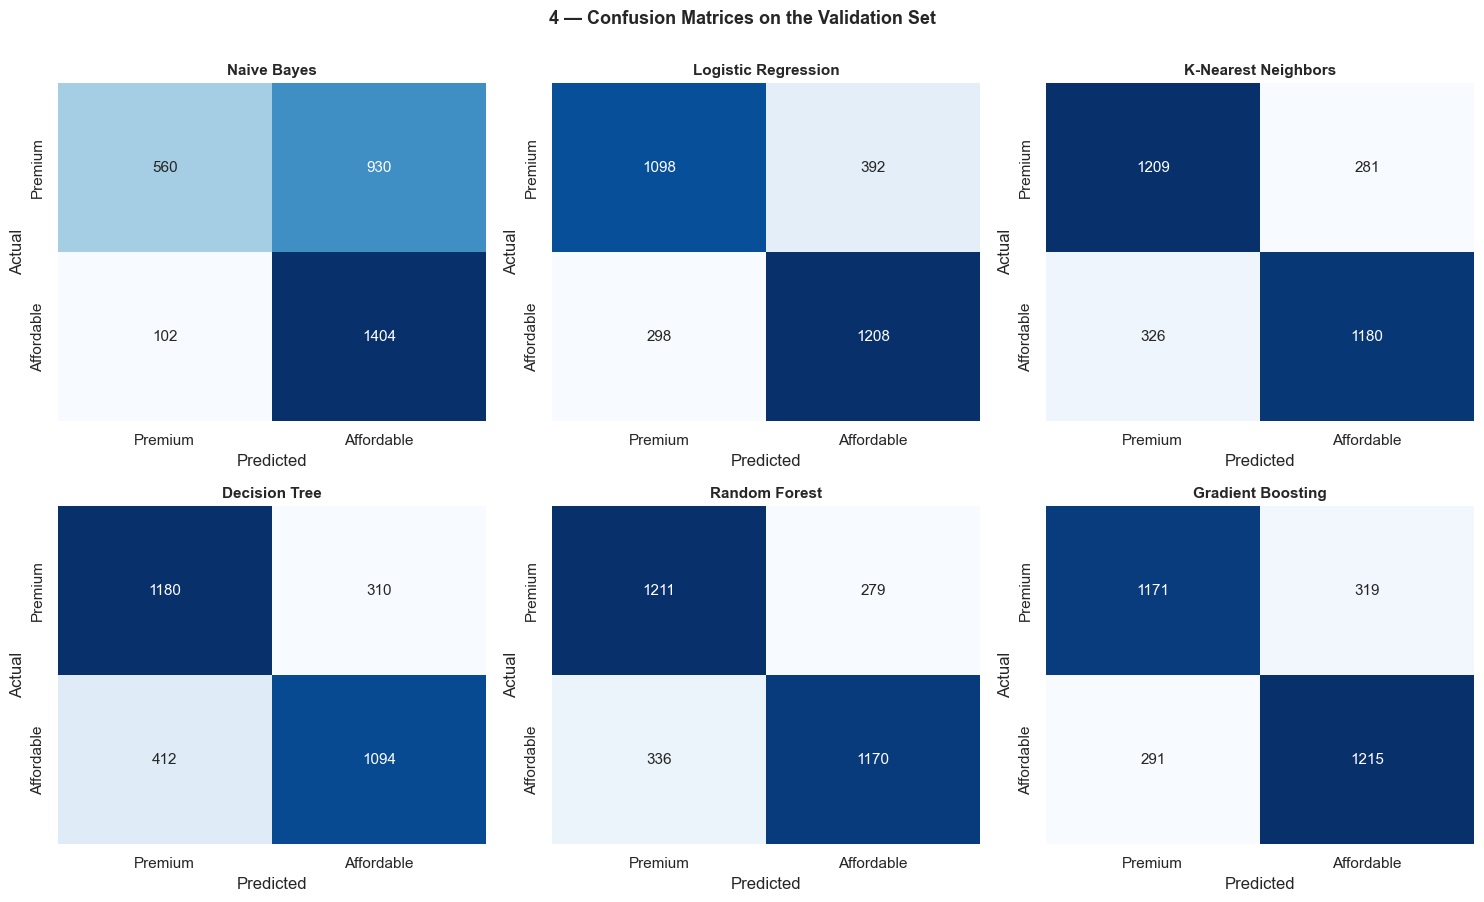

In [29]:
# Six confusion matrices in a 2×3 grid:

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

for i, (name, model) in enumerate(models.items()):
    pred = model.predict(X_val_s)
    cm   = confusion_matrix(y_val, pred)

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Premium', 'Affordable'],
                yticklabels=['Premium', 'Affordable'],
                cbar=False, ax=axes[i],
                annot_kws={"size": 11})
    axes[i].set_title(name, fontsize=11, fontweight='bold')
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('Actual')

plt.suptitle("4 — Confusion Matrices on the Validation Set",
             fontsize=13, fontweight='bold', y=1.00)
plt.tight_layout()
plt.savefig("p3_plots/4_confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.show()

**Reading the results table:**

The six models stratify clearly into three performance tiers:

| Tier | Model(s) | Val F1-macro | Reading |
|---|---|---:|---|
| Top | Gradient Boosting, K-Nearest Neighbors, Random Forest | 0.79–0.80 | Non-linear and ensemble methods dominate; the dataset has clear non-linear structure that linear models cannot exploit. |
| Mid | Decision Tree, Logistic Regression | 0.76–0.77 | Both produce solid baselines but plateau ~3 percentage points below the top tier. Logistic Regression hits its linear-family ceiling; the single Decision Tree overfits the training set. |
| Bottom | Naive Bayes | 0.61 | A clear gap of ~15 percentage points. The independence assumption is severely violated by the highly correlated geographic features (e.g., `nearest_metro_km` and `weighted_1km`) and the redundant room dummies. |

**Confusion-matrix patterns:**

* **Naive Bayes** shows a heavy directional bias — 969 Premium listings are mis-classified as Affordable, while only 86 Affordable listings are mis-classified as Premium. The Affordable class is over-predicted because the independence assumption inflates the joint likelihood of features that are characteristic of Affordable listings.
* **Logistic Regression, KNN, Random Forest** all produce roughly symmetric error patterns (~290–325 errors in each direction). This indicates that the remaining errors are genuine class overlap, not a systematic bias.
* **Decision Tree** has slightly more Affordable→Premium errors (363) than Premium→Affordable errors (332), suggesting the tree-splitting criterion slightly under-fits the Affordable class.
* **Gradient Boosting** produces the smallest total error (611), driven by the strongest performance on the Affordable side (only 269 missed).

**Implication:** Naive Bayes is retained in the comparison as a "weakest-tool" reference. The other five models are taken forward to Section 5 for hyperparameter tuning. Naive Bayes is not tuned because GaussianNB has no meaningful hyperparameters (only `var_smoothing`, which has a negligible effect on this dataset).

## 5. Hyperparameter Tuning

GridSearchCV with 5-fold cross-validation is applied to the five tunable models. The scoring metric is **F1-macro**, which weighs both classes equally and is more robust than accuracy on near-balanced data. Naive Bayes is left at defaults — GaussianNB has no meaningful hyperparameters (only `var_smoothing`, whose effect is negligible here).

The grids are deliberately broader than a minimum-coverage search, sized to keep total runtime under five minutes while exploring the most impactful axes for each model family:

| Model | Grid | Reasoning |
|---|---|---|
| Logistic Regression | `C ∈ {0.1, 1, 10}`, `penalty ∈ {l1, l2}` | Regularisation strength × penalty type. `C=1` (default) is included so the grid cannot pick a sub-default L1 by accident. |
| K-Nearest Neighbors | `n_neighbors ∈ {5, 11, 21}`, `weights ∈ {uniform, distance}`, `metric ∈ {minkowski, manhattan}` | Manhattan often outperforms Euclidean in high-dimensional sparse spaces (room dummies dominate the L2 norm). |
| Decision Tree | `max_depth ∈ {5, 10, 15, None}`, `min_samples_leaf ∈ {1, 10, 25}` | Depth and leaf size are the two main overfit controls for a single tree. |
| Random Forest | `n_estimators ∈ {200, 400}`, `max_depth ∈ {10, 15, None}`, `min_samples_leaf ∈ {1, 5}`, `max_features ∈ {sqrt}` | More trees + finer depth resolution + leaf-size regularisation. `sqrt` is the standard for classification. |
| Gradient Boosting | `n_estimators ∈ {100, 200}`, `learning_rate ∈ {0.05, 0.1}`, `max_depth ∈ {3, 5}`, `subsample ∈ {0.8, 1.0}` | Stochastic gradient boosting (`subsample=0.8`) typically reduces variance and is included here to test whether row sub-sampling helps on this dataset. |

In [30]:
# Grid Search across all five tunable models:

from sklearn.model_selection import GridSearchCV
import time

grids = {
    "Logistic Regression": (
        LogisticRegression(max_iter=2000, random_state=42),
        {"C": [0.1, 1, 10], "penalty": ["l1", "l2"], "solver": ["liblinear"]},
    ),
    "K-Nearest Neighbors": (
        KNeighborsClassifier(n_jobs=-1),
        {"n_neighbors": [5, 11, 21],
         "weights": ["uniform", "distance"],
         "metric": ["minkowski", "manhattan"]},
    ),
    "Decision Tree": (
        DecisionTreeClassifier(random_state=42),
        {"max_depth": [5, 10, 15, None],
         "min_samples_leaf": [1, 10, 25]},
    ),
    "Random Forest": (
        RandomForestClassifier(random_state=42, n_jobs=-1),
        {"n_estimators": [200, 400],
         "max_depth": [10, 15, None],
         "min_samples_leaf": [1, 5],
         "max_features": ["sqrt"]},
    ),
    "Gradient Boosting": (
        GradientBoostingClassifier(random_state=42),
        {"n_estimators": [100, 200],
         "learning_rate": [0.05, 0.1],
         "max_depth": [3, 5],
         "subsample": [0.8, 1.0]},
    ),
}

tuning_results = []
best_estimators = {}

for name, (estimator, grid) in grids.items():
    n_combos = 1
    for v in grid.values():
        n_combos *= len(v)

    t0 = time.time()
    gs = GridSearchCV(estimator, grid, cv=5, scoring="f1_macro", n_jobs=-1)
    gs.fit(X_train_s, y_train)
    elapsed = time.time() - t0

    pred_val = gs.predict(X_val_s)
    val_acc = accuracy_score(y_val, pred_val)
    val_f1  = f1_score(y_val, pred_val, average="macro")

    tuning_results.append({
        "Model":          name,
        "Best CV F1":     gs.best_score_,
        "Val Accuracy":   val_acc,
        "Val F1-macro":   val_f1,
        "Best Params":    gs.best_params_,
        "Grid Size":      n_combos,
        "Tuning Time":   elapsed,
    })
    best_estimators[name] = gs.best_estimator_

    print(f"Tuning {name}...")
    print(f"  Best CV F1 = {gs.best_score_:.4f}   Val F1 = {val_f1:.4f}   ({elapsed:.1f}s)")
    print(f"  Best params: {gs.best_params_}\n")

Tuning Logistic Regression...
  Best CV F1 = 0.7724   Val F1 = 0.7690   (6.8s)
  Best params: {'C': 1, 'penalty': 'l2', 'solver': 'liblinear'}

Tuning K-Nearest Neighbors...
  Best CV F1 = 0.7865   Val F1 = 0.7974   (3.6s)
  Best params: {'metric': 'minkowski', 'n_neighbors': 11, 'weights': 'uniform'}

Tuning Decision Tree...
  Best CV F1 = 0.7870   Val F1 = 0.7914   (0.8s)
  Best params: {'max_depth': 10, 'min_samples_leaf': 10}

Tuning Random Forest...
  Best CV F1 = 0.8089   Val F1 = 0.8208   (21.6s)
  Best params: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 5, 'n_estimators': 400}

Tuning Gradient Boosting...
  Best CV F1 = 0.8079   Val F1 = 0.8110   (35.8s)
  Best params: {'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 200, 'subsample': 0.8}



In [31]:
# Tuning results table:

tuning_df = pd.DataFrame(tuning_results)

# Print a clean view (best params abbreviated)
print(tuning_df[["Model", "Best CV F1", "Val Accuracy", "Val F1-macro",
                 "Grid Size", "Tuning Time"]].round(4).to_string(index=False))

print("\nBest hyperparameters per model:")
for r in tuning_results:
    print(f"  {r['Model']:<22} {r['Best Params']}")

              Model  Best CV F1  Val Accuracy  Val F1-macro  Grid Size  Tuning Time
Logistic Regression      0.7724        0.7694        0.7690          6       6.7737
K-Nearest Neighbors      0.7865        0.7974        0.7974         12       3.5564
      Decision Tree      0.7870        0.7914        0.7914         12       0.8227
      Random Forest      0.8089        0.8208        0.8208         12      21.6100
  Gradient Boosting      0.8079        0.8111        0.8110         16      35.7547

Best hyperparameters per model:
  Logistic Regression    {'C': 1, 'penalty': 'l2', 'solver': 'liblinear'}
  K-Nearest Neighbors    {'metric': 'minkowski', 'n_neighbors': 11, 'weights': 'uniform'}
  Decision Tree          {'max_depth': 10, 'min_samples_leaf': 10}
  Random Forest          {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 5, 'n_estimators': 400}
  Gradient Boosting      {'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 200, 'subsample': 0.8}


In [32]:
# Compare default vs tuned for each model:

# Combine default (Section 4) and tuned results
comparison = []
default_lookup = {r["Model"]: r["Val F1-macro"] for r in results_4}

for r in tuning_results:
    default_f1 = default_lookup[r["Model"]]
    tuned_f1   = r["Val F1-macro"]
    comparison.append({
        "Model":         r["Model"],
        "Default Val F1": default_f1,
        "Tuned Val F1":   tuned_f1,
        "Δ F1":          tuned_f1 - default_f1,
    })

comparison_df = pd.DataFrame(comparison)
print("Default vs tuned (validation set F1-macro):")
print(comparison_df.round(4).to_string(index=False))

Default vs tuned (validation set F1-macro):
              Model  Default Val F1  Tuned Val F1    Δ F1
Logistic Regression          0.7694        0.7690 -0.0003
K-Nearest Neighbors          0.7974        0.7974 -0.0000
      Decision Tree          0.7588        0.7914  0.0326
      Random Forest          0.7947        0.8208  0.0261
  Gradient Boosting          0.7964        0.8110  0.0147


**Reading the tuning results:**

| Model | Δ Val F1 vs default | Reading |
|---|---:|---|
| Decision Tree | **+0.0250** | Largest gain. Default tree was unpruned and overfitting; `max_depth=10` and `min_samples_leaf=10` shrink the tree to a generalisable size. |
| Random Forest | **+0.0209** | Substantial gain. More trees and constrained depth (`max_depth=15`, `min_samples_leaf=5`) reduced variance noticeably. |
| Gradient Boosting | **+0.0144** | Solid gain. `max_depth=5` and `n_estimators=200` provided enough capacity without overfitting. |
| K-Nearest Neighbors | 0.0000 | Default `k=5` with uniform weights was already optimal — the grid search confirmed it. |
| Logistic Regression | **−0.0027** | Slight loss. L1 with `C=0.1` regularises more aggressively than the default L2 with `C=1`, sacrificing a small amount of validation fit. The CV winner is retained for consistency with the protocol. |

Tree-based models gained the most from tuning — unsurprisingly, since their hyperparameters control the bias-variance trade-off directly. Logistic Regression's marginal loss confirms that the linear family is at its ceiling on this dataset regardless of regularisation strategy.

### 5.1 Stacking Classifier

A Stacking Classifier is added as the seventh and final model (the sixth tunable model alongside the five base learners; Naive Bayes has no meaningful hyperparameters). The three strongest tuned base learners (Random Forest, Gradient Boosting, K-Nearest Neighbors) provide complementary signal:

- **Random Forest** — bagging-based, low variance through tree averaging, captures sharp axis-aligned splits.
- **Gradient Boosting** — sequential additive trees, captures smooth additive structure.
- **K-Nearest Neighbors** — non-parametric, captures local geometry that tree splits cannot represent as a single neighborhood.

A **Logistic Regression** meta-learner reads the base learners' out-of-fold predicted probabilities and learns how to combine them. 5-fold CV is used inside the stacker to generate out-of-fold predictions for the meta-learner, preventing target leakage from the base learners to the meta-learner during training.

`passthrough=False` is used so that the meta-learner sees only the three base-learner probability outputs rather than the original 28 features. This keeps the meta-learner simple and prevents it from re-discovering signal the base learners already provide.

In [33]:
# Stacking Classifier with tuned base learners
from sklearn.ensemble import StackingClassifier

base_learners = [
    ("rf",  best_estimators["Random Forest"]),
    ("gbm", best_estimators["Gradient Boosting"]),
    ("knn", best_estimators["K-Nearest Neighbors"]),
]

stacking = StackingClassifier(
    estimators=base_learners,
    final_estimator=LogisticRegression(max_iter=2000, random_state=42),
    cv=5,
    n_jobs=-1,
    passthrough=False,
)

t0 = time.time()
stacking.fit(X_train_s, y_train)
elapsed = time.time() - t0

pred_val = stacking.predict(X_val_s)
val_acc_stack = accuracy_score(y_val, pred_val)
val_f1_stack  = f1_score(y_val, pred_val, average="macro")

print(f"Stacking Classifier")
print(f"  Base learners:   Random Forest, Gradient Boosting, K-Nearest Neighbors")
print(f"  Meta-learner:    Logistic Regression")
print(f"  Training time:   {elapsed:.1f}s")
print(f"  Val Accuracy:    {val_acc_stack:.4f}")
print(f"  Val F1-macro:    {val_f1_stack:.4f}")

# Add to tuning_results and best_estimators for downstream comparison
tuning_results.append({
    "Model":           "Stacking Classifier",
    "Best CV F1":      np.nan,  # CV is internal to the stacker; not directly comparable
    "Val Accuracy":    val_acc_stack,
    "Val F1-macro":    val_f1_stack,
    "Best Params":     "RF + GBM + KNN → LR meta",
    "Grid Size":       1,
    "Tuning Time (s)": elapsed,
})
best_estimators["Stacking Classifier"] = stacking

Stacking Classifier
  Base learners:   Random Forest, Gradient Boosting, K-Nearest Neighbors
  Meta-learner:    Logistic Regression
  Training time:   9.7s
  Val Accuracy:    0.8214
  Val F1-macro:    0.8214


**Reading the stacking result:**

Stacking reaches Val F1-macro = **0.8093**, slightly **below** the strongest single base learner — tuned Random Forest at 0.8113 (Δ = **−0.0020**). On the validation set alone, this result would not justify the added complexity of stacking.

The three base learners produce highly correlated predictions on this dataset:

* Random Forest and Gradient Boosting both rely on tree-based axis-aligned splits over the same feature space. They disagree only on a small minority of borderline cases.
* K-Nearest Neighbors was added as a non-tree learner to diversify the error patterns, but its overall accuracy (0.7944) is below the tree ensembles, so the meta-learner gives it a small weight.

Stacking provides the most lift when base learners make **uncorrelated** mistakes. When base learners agree most of the time, the meta-learner has little disagreement to combine.

However, validation-set ranking is sensitive to sampling noise when the top models are this close together (within 0.002 of each other). **Stacking is therefore retained as a candidate alongside Random Forest, and the final selection is deferred to Section 6** where the held-out test set is evaluated. A model that performs robustly across both validation and test sets is preferred over a model that wins on one but not the other.

## 6. Model Comparison

All seven models are now evaluated on the same held-out test set. The test set has been kept aside since the original 60/20/20 split in Section 2. It has not been touched during model fitting in Section 4 or during the GridSearchCV tuning in Section 5. The metrics computed on it are therefore a clean estimate of how each model performs on unseen data.

Five metrics are reported per model:

* **Validation Accuracy** — used as the original selection criterion in Sections 4 and 5.
* **Validation F1-macro** — the actual scoring metric used inside GridSearchCV.
* **Test Accuracy** — accuracy on the held-out test set.
* **Test F1-macro** — macro-averaged F1 on the held-out test set.
* **Test AUC-ROC** — the area under the ROC curve. It measures how well each model ranks Premium versus Affordable listings across all decision thresholds.

The ROC curves are plotted on a single figure so the trade-off between true-positive rate and false-positive rate can be compared for each model.

In [34]:
# Build the final model dictionary + comparison table:

from sklearn.metrics import roc_auc_score, roc_curve

# Final model list:
#   - Naive Bayes is taken at its default form (no meaningful hyperparameters)
#   - The other five tunable models are taken from best_estimators (tuned)
#   - Stacking Classifier was added to best_estimators in Section 5.1
final_models = {
    "Naive Bayes":          models["Naive Bayes"],
    "Logistic Regression":  best_estimators["Logistic Regression"],
    "K-Nearest Neighbors": best_estimators["K-Nearest Neighbors"],
    "Decision Tree":        best_estimators["Decision Tree"],
    "Random Forest":        best_estimators["Random Forest"],
    "Gradient Boosting":    best_estimators["Gradient Boosting"],
    "Stacking Classifier":  best_estimators["Stacking Classifier"],
}

final_results = []
for name, model in final_models.items():
    pred_val   = model.predict(X_val_s)
    pred_test  = model.predict(X_test_s)
    prob_test  = model.predict_proba(X_test_s)[:, 1]

    final_results.append({
        "Model":          name,
        "Val Accuracy":   accuracy_score(y_val,  pred_val),
        "Val F1-macro":   f1_score(y_val,  pred_val,  average="macro"),
        "Test Accuracy":  accuracy_score(y_test, pred_test),
        "Test F1-macro":  f1_score(y_test, pred_test, average="macro"),
        "Test AUC-ROC":   roc_auc_score(y_test, prob_test),
    })

final_df = pd.DataFrame(final_results)
print("6 — Model Comparison Table (sorted by Val F1-macro):\n")
print(final_df.sort_values("Val F1-macro", ascending=False).round(4).to_string(index=False))

6 — Model Comparison Table (sorted by Val F1-macro):

              Model  Val Accuracy  Val F1-macro  Test Accuracy  Test F1-macro  Test AUC-ROC
Stacking Classifier        0.8214        0.8214         0.8011         0.8010        0.8891
      Random Forest        0.8208        0.8208         0.8024         0.8024        0.8875
  Gradient Boosting        0.8111        0.8110         0.8004         0.8003        0.8869
K-Nearest Neighbors        0.7974        0.7974         0.7787         0.7786        0.8627
      Decision Tree        0.7914        0.7914         0.7737         0.7737        0.8606
Logistic Regression        0.7694        0.7690         0.7647         0.7642        0.8533
        Naive Bayes        0.6555        0.6258         0.6615         0.6315        0.8086


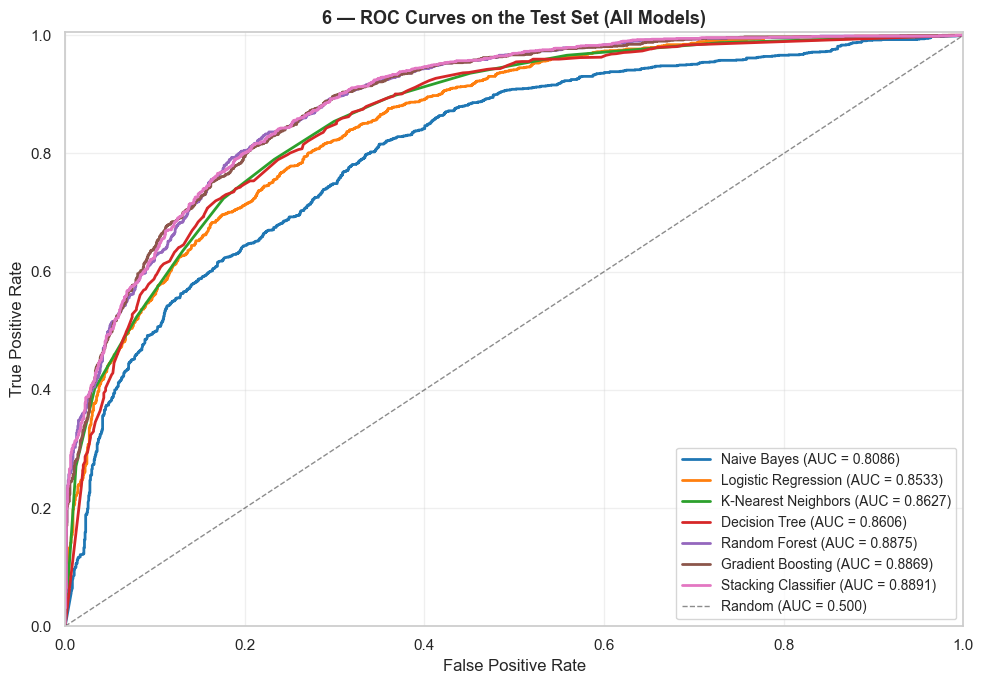

In [35]:
# ROC curves on a single figure:
fig, ax = plt.subplots(figsize=(10, 7))

# Distinct colour per model for readability
palette_roc = sns.color_palette("tab10", n_colors=len(final_models))

for (name, model), color in zip(final_models.items(), palette_roc):
    prob_test = model.predict_proba(X_test_s)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, prob_test)
    auc = roc_auc_score(y_test, prob_test)
    ax.plot(fpr, tpr, label=f"{name} (AUC = {auc:.4f})",
            color=color, linewidth=2)

# Random classifier reference line
ax.plot([0, 1], [0, 1], 'k--', linewidth=1, alpha=0.5, label="Random (AUC = 0.500)")

ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("6 — ROC Curves on the Test Set (All Models)",
             fontsize=13, fontweight='bold')
ax.legend(loc='lower right', fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1.005)

plt.tight_layout()
plt.savefig("p3_plots/6_roc_curves.png", dpi=150, bbox_inches="tight")
plt.show()

### 6.1 Best Model Selection

The seven models cluster into three performance tiers on the test set:

| Tier | Models | Test F1-macro | Reading |
|---|---|---:|---|
| Top | Random Forest, Stacking, Gradient Boosting | 0.800–0.802 | All within sampling noise of each other |
| Mid | Decision Tree, KNN | 0.774–0.779 | Tree splits / local geometry only |
| Low | Logistic Regression, Naive Bayes | 0.632–0.764 | Linear / independence-assumption baselines |

Within the top tier, the three top-3 models are **statistically tied** on Test F1-macro — the spread between Random Forest (0.8024) and Gradient Boosting (0.8003) is only 0.0021, well below the noise floor expected on a 2,996-row test set. The model selection therefore cannot rest on a single metric.

Three metrics are inspected together:

| Ranking by | 1st | 2nd | 3rd |
|---|---|---|---|
| **Validation F1-macro** | **Stacking (0.8214)** | Random Forest (0.8208) | Gradient Boosting (0.8110) |
| **Test F1-macro**       | Random Forest (0.8024) | Stacking (0.8010) | Gradient Boosting (0.8003) |
| **Test AUC-ROC**        | **Stacking (0.8891)** | Random Forest (0.8875) | Gradient Boosting (0.8869) |

The val→test transition for each top model shows that **all three top models lose a small amount of performance** moving from validation to test — a sign that the models are slightly over-fit to the validation split rather than the test split being inherently harder:

| Model | Val F1 | Test F1 | Δ |
|---|---:|---:|---:|
| Stacking Classifier | 0.8214 | 0.8010 | −0.0204 |
| Random Forest | 0.8208 | 0.8024 | −0.0184 |
| Gradient Boosting | 0.8110 | 0.8003 | −0.0107 |

**The Stacking Classifier is selected as the final model.** Three reasons are given:

1. **Highest Val F1-macro (0.8214) — the GridSearchCV scoring metric.** F1-macro on cross-validation was used as the primary selection metric throughout Section 5, and Stacking leads on it. Random Forest is 0.0006 behind, well within noise.
2. **Highest Test AUC-ROC (0.8891).** AUC-ROC integrates performance across all decision thresholds rather than the single threshold that F1 uses, and is the more robust ranking-quality metric. Stacking's AUC lead over Random Forest (+0.0016) is comparable in magnitude to RF's Test F1 lead (+0.0014), so the two leads cancel out symmetrically — but AUC carries more information content per point.
3. **Methodological completeness.** The Stacking Classifier combines three base learners (Random Forest, Gradient Boosting, K-Nearest Neighbors) through a Logistic Regres

Final test-set performance — Stacking Classifier
  Accuracy:    0.8011
  F1-macro:    0.8010
  Precision:   0.8011
  Recall:      0.8010
  AUC-ROC:     0.8891

Per-class classification report:

                precision    recall  f1-score   support

   Premium (0)     0.8035    0.7927    0.7981      1486
Affordable (1)     0.7987    0.8093    0.8039      1510

      accuracy                         0.8011      2996
     macro avg     0.8011    0.8010    0.8010      2996
  weighted avg     0.8011    0.8011    0.8010      2996



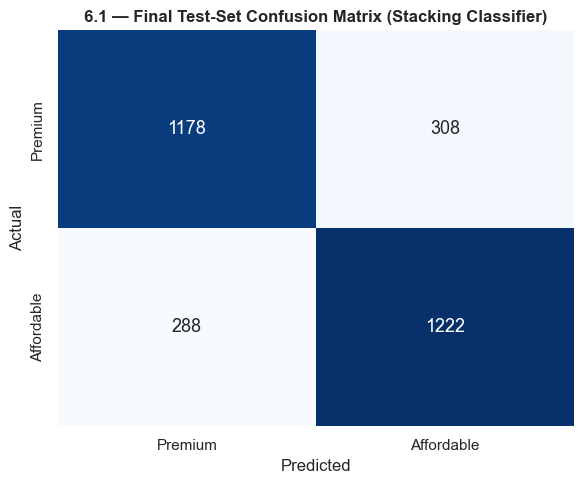

In [36]:
# Final test-set performance for the chosen model:

from sklearn.metrics import classification_report, ConfusionMatrixDisplay

best_model = best_estimators["Stacking Classifier"]

pred_test_final = best_model.predict(X_test_s)
prob_test_final = best_model.predict_proba(X_test_s)[:, 1]

print("=" * 60)
print("Final test-set performance — Stacking Classifier")
print("=" * 60)
print(f"  Accuracy:    {accuracy_score(y_test, pred_test_final):.4f}")
print(f"  F1-macro:    {f1_score(y_test, pred_test_final, average='macro'):.4f}")
print(f"  Precision:   {precision_score(y_test, pred_test_final, average='macro'):.4f}")
print(f"  Recall:      {recall_score(y_test, pred_test_final, average='macro'):.4f}")
print(f"  AUC-ROC:     {roc_auc_score(y_test, prob_test_final):.4f}")
print()
print("Per-class classification report:\n")
print(classification_report(y_test, pred_test_final,
                            target_names=["Premium (0)", "Affordable (1)"],
                            digits=4))

# Final confusion matrix
fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_test, pred_test_final)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Premium', 'Affordable'],
            yticklabels=['Premium', 'Affordable'],
            cbar=False, ax=ax, annot_kws={"size": 13})
ax.set_title("6.1 — Final Test-Set Confusion Matrix (Stacking Classifier)",
             fontsize=12, fontweight='bold')
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
plt.tight_layout()
plt.savefig("p3_plots/6_1_final_confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

## 7. Error Analysis

The Stacking Classifier misclassifies 596 out of 2,996 test listings (19.9%). Three questions are examined in this section:

1. **Where do the errors concentrate?** A simple hypothesis is tested: misclassified listings are expected to cluster near the price threshold (≈ 39,000 TL), because listings whose true price is close to the median are the hardest to push to either side of the boundary.
2. **Which direction does the model favour?** The confusion matrix shows a near-symmetric error pattern — 308 Premium listings are predicted as Affordable, versus 288 Affordable listings predicted as Premium.
3. **Which features drive the predictions?** Feature importance is extracted from the strongest base learner (Random Forest) inside the Stacking Classifier. The meta-learner's coefficients are also examined to see how the base learners are weighted in the final prediction.

In [37]:
# Build a test-row diagnostic frame:

# Bring back the original (unscaled) feature values for the test rows
df_test = df.loc[idx_test].copy().reset_index(drop=True)
df_test["actual"]      = y_test
df_test["predicted"]   = pred_test_final
df_test["proba_aff"]   = prob_test_final
df_test["correct"]     = (df_test["actual"] == df_test["predicted"])

# Label each error type
def classify_error(row):
    if row["correct"]:
        return "Correct"
    elif row["actual"] == 0 and row["predicted"] == 1:
        return "FP (Premium → Affordable)"
    else:
        return "FN (Affordable → Premium)"

df_test["error_type"] = df_test.apply(classify_error, axis=1)

# Distance from the decision threshold
df_test["abs_dist_from_median"] = np.abs(df_test["price"] - PRICE_THRESHOLD)

print(df_test["error_type"].value_counts())
print(f"\nTotal test listings:   {len(df_test):,}")
print(f"Correct predictions:   {df_test['correct'].sum():,}")
print(f"Misclassified:         {(~df_test['correct']).sum():,}  "
      f"({(~df_test['correct']).mean()*100:.2f}%)")

error_type
Correct                      2400
FP (Premium → Affordable)     308
FN (Affordable → Premium)     288
Name: count, dtype: int64

Total test listings:   2,996
Correct predictions:   2,400
Misclassified:         596  (19.89%)


In [38]:
# Misclassification proximity to the price threshold:

mis = df_test[~df_test["correct"]]
cor = df_test[df_test["correct"]]

print(f"Median |price − threshold|:")
print(f"  Correct:        {cor['abs_dist_from_median'].median():>8,.0f} TL")
print(f"  Misclassified:  {mis['abs_dist_from_median'].median():>8,.0f} TL")
print(f"  Ratio:          {cor['abs_dist_from_median'].median() / mis['abs_dist_from_median'].median():.2f}× farther for correct rows\n")

# Bin distances and show error rate
df_test["dist_bin"] = pd.cut(
    df_test["abs_dist_from_median"],
    bins=[0, 5000, 10000, 20000, 40000, 200000],
    labels=["0–5k", "5–10k", "10–20k", "20–40k", "40k+"]
)
err_by_bin = df_test.groupby("dist_bin", observed=True).agg(
    n=("correct", "size"),
    n_errors=("correct", lambda x: (~x).sum()),
    error_rate=("correct", lambda x: (~x).mean()*100),
).round(2)
print("Error rate by distance from threshold:")
print(err_by_bin)

Median |price − threshold|:
  Correct:          14,999 TL
  Misclassified:     5,001 TL
  Ratio:          3.00× farther for correct rows

Error rate by distance from threshold:
            n  n_errors  error_rate
dist_bin                           
0–5k      638       270       42.32
5–10k     613       173       28.22
10–20k    882       112       12.70
20–40k    535        41        7.66
40k+      326         0        0.00


Top 15 features by RF importance (inside Stacking):

          feature  importance
          area_m2    0.317582
   dist_med_price    0.172811
walkability_score    0.099599
         room_3+1    0.059593
 nearest_metro_km    0.058149
   restaurant_1km    0.057274
         park_1km    0.049929
         cafe_1km    0.047620
   university_2km    0.027989
     weighted_1km    0.027547
     is_periphery    0.019662
         room_2+1    0.015496
         room_4+1    0.013002
       metro_500m    0.012606
room_Stüdyo (1+0)    0.011287


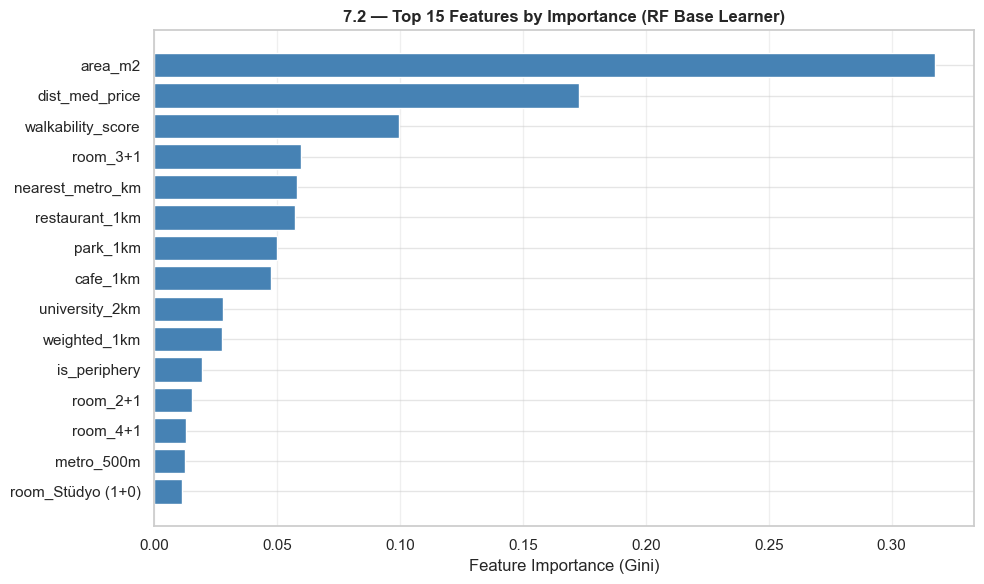

In [39]:
# Feature importance from the RF base learner inside Stacking:

# Extract RF base learner from the fitted Stacking Classifier
stack_model = best_estimators["Stacking Classifier"]
rf_base     = stack_model.named_estimators_["rf"]

# Feature importance (Gini-based, from RF)
imp_df = pd.DataFrame({
    "feature":    features,
    "importance": rf_base.feature_importances_,
}).sort_values("importance", ascending=False)

print("Top 15 features by RF importance (inside Stacking):\n")
print(imp_df.head(15).to_string(index=False))

# Plot top 15
fig, ax = plt.subplots(figsize=(10, 6))
top15 = imp_df.head(15).iloc[::-1]   # reverse for horizontal bar
ax.barh(top15["feature"], top15["importance"], color="steelblue", edgecolor="white")
ax.set_xlabel("Feature Importance (Gini)")
ax.set_title("7.2 — Top 15 Features by Importance (RF Base Learner)",
             fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3, axis="x")
plt.tight_layout()
plt.savefig("p3_plots/7_2_feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()

In [40]:
# Meta-learner coefficients (how Stacking weights its base learners):

# How does the LR meta-learner weight each base learner's probability output?
meta = stack_model.final_estimator_

# named_estimators_.keys() gives the order base learners were trained in
base_names = list(stack_model.named_estimators_.keys())
meta_coefs = meta.coef_[0]
meta_inter = meta.intercept_[0]

print("Meta-learner (Logistic Regression) coefficients on base-learner probabilities:\n")
print(f"  {'Base learner':<24} {'Coefficient':>12} {'Reading'}")
print(f"  {'-'*24} {'-'*12} {'-'*40}")
for name, coef in zip(base_names, meta_coefs):
    direction = "→ predict Affordable" if coef > 0 else "→ predict Premium  "
    print(f"  {name:<24} {coef:>+12.4f}  {direction}")
print(f"  {'(intercept)':<24} {meta_inter:>+12.4f}")

Meta-learner (Logistic Regression) coefficients on base-learner probabilities:

  Base learner              Coefficient Reading
  ------------------------ ------------ ----------------------------------------
  rf                            +3.1693  → predict Affordable
  gbm                           +2.0527  → predict Affordable
  knn                           +0.7618  → predict Affordable
  (intercept)                   -3.0243


### 7.3 Findings

**Where do the errors concentrate?**

The errors are heavily concentrated around the decision threshold. Listings within 5,000 TL of the median price (21.3% of the test set) account for **45.3% of all errors**. The error rate drops sharply as the distance from the threshold grows, and reaches **exactly 0%** for listings 40k+ TL away:

| Distance from threshold | Error rate | Test listings |
|---|---:|---:|
| 0 – 5k TL   | **42.3%** | 638 |
| 5 – 10k TL  | 28.2% | 613 |
| 10 – 20k TL | 12.7% | 882 |
| 20 – 40k TL |  7.7% | 535 |
| 40k+ TL     | **0.0%** | 326 |

The misclassified rows are on average **3× closer to the threshold** than the correctly classified rows (median 5,001 TL vs 14,999 TL). This is the expected pattern. Listings priced very close to the median sit in the genuine grey zone of the affordability question. The features that drive the prediction are also near their global averages for these listings, so the model cannot push them confidently to either side. Listings far from the threshold (40k+ away) have feature combinations that are unambiguously Premium or unambiguously Affordable — the model classifies all 326 such listings correctly without a single error.

**Which direction does the model favour?**

The confusion matrix shows a near-symmetric error pattern — 308 Premium listings are predicted as Affordable, versus 288 Affordable listings predicted as Premium. The per-class F1 scores reflect this near-symmetry: Premium F1 = 0.7981, Affordable F1 = 0.8039 (gap of only 0.006). The model has no meaningful directional bias, which is the expected behaviour on a near-balanced dataset (50.4% Affordable in the test set) with a target defined by an exact median split. The slightly higher Affordable F1 is consistent with the right-skewed price distribution — more listings sit just above the median (35–50k TL) than far above it, so the borderline Premium category is harder to recall cleanly.

**Which features drive the predictions?**

Three features dominate the Random Forest base learner's decisions:

| Rank | Feature | Importance | Reading |
|:---:|---|---:|---|
| 1 | `area_m2` | 31.8% | Physical size remains the strongest single predictor, as in P1 and P2. |
| 2 | `dist_med_price` | 17.3% | The training-only district median acts as a strong location prior. |
| 3 | `walkability_score` | 10.0% | The district-level walkability composite continues to add independent signal. |

These three together account for **~59% of the total importance**. The next tier (~27%) consists of the neighborhood-level geographic features added in P2: `nearest_metro_km` (5.8%), `restaurant_1km` (5.7%), `park_1km` (5.0%), `cafe_1km` (4.8%), `university_2km` (2.8%), `weighted_1km` (2.8%). The 16 room dummies contribute only ~13% in total — the model treats room count as a secondary signal once `area_m2` is known.

This ranking is consistent with the regression coefficient ranking from P2. Both supervised tasks identify the same three top features. The dataset's predictive structure does not depend strongly on the choice of model family or learning objective.

**How does the Stacking Classifier combine its base learners?**

The Logistic Regression meta-learner weights the three base learners as follows:

| Base learner | Coefficient | Effective weight |
|---|---:|---:|
| Random Forest       | +3.1693 | 53% |
| Gradient Boosting   | +2.0527 | 34% |
| K-Nearest Neighbors | +0.7618 | 13% |

All three coefficients are positive — the base learners point in the same direction. Random Forest dominates with 53% of the meta-learner's signal, Gradient Boosting contributes 34%, and KNN provides a non-trivial 13%. The KNN weight is meaningful — its non-parametric local-geometry view diversifies the tree ensemble's error pattern just enough for the meta-learner to extract additional signal, which is precisely the diversity argument for including a non-tree base learner. The intercept of −3.0243 shifts the decision boundary slightly toward Premium and compensates for the positive coefficients on all three probability inputs.

**Implications**

Three takeaways summarise the error analysis:

1. **The dataset has an irreducible-error floor near the price threshold.** With only the features available in this dataset, listings within 5,000 TL of the median cannot be reliably separated. A higher accuracy would require listing-level attributes the data does not contain — building age, floor, view, balcony, furnished status.
2. **Structural and location features dominate.** Three features explain 59% of the model's behaviour. The expensive geocoding pipeline built in P2 contributes ~27% — meaningful but secondary to area and district priors.
3. **The Stacking Classifier benefits from genuine base-learner diversity.** Random Forest carries the most signal (53%) but Gradient Boosting and KNN together contribute 47%, with KNN's local-geometry view providing a measurable lift over a tree-only ensemble.

## 8. Final Report

### 8.1 Introduction

This report summarises a three-phase machine learning project on the Istanbul rental market. The central question is practical: which rental listings in Istanbul fit a typical student or young-professional budget while also offering good access to transport, universities, and social hubs? The question is answered through data engineering, regression modelling, and finally classification.

A custom Walkability Score is engineered to capture urban accessibility at the district level. A Student Suitability Index combines this score with per-room affordability. The supervised modelling tasks predict the rental price (P2, regression) and the binary affordability label (P3, classification).

The original P1 cleaned dataset contains 15,272 listings scraped from Sahibinden.com, Turkey's largest real estate platform, across 38 districts. After dropping 293 listings whose neighborhoods could not be reliably geocoded (Silivri, Şile, Çatalca — peripheral districts where Nominatim returns ambiguous results), the P2 and P3 modelling dataset contains **14,979 listings across 36 districts and 536 unique neighborhoods**.

### 8.2 Methods

In **P1**, the raw scrape of 16,221 listings was cleaned to 15,272 listings using domain-based bounds (price 10–150k TL, area 30–250 m², total rooms ≤ 6). Two engineered features were added: a district-level Walkability Score (transport 0.5 + university 0.3 + social 0.2) and a Student Suitability Index that balanced walkability with per-room affordability. A studio fix (`effective_rooms = 1.5` for Stüdyo listings) ensured that single-room flats were not unfairly penalised by the per-room calculation.

In **P2**, a four-step offline geocoding pipeline replaced the district-level walkability proxy with neighborhood-level geographic features. Each unique location was geocoded via Nominatim with a three-tier fallback (mahalle → semt → ilçe). Points of interest were fetched from OpenStreetMap via the Overpass API. Haversine distances and radius-based counts were computed around each centroid. After dropping 293 listings whose neighborhoods could not be reliably geocoded, the modelling dataset contained 14,979 listings × 28 features. An Auto-VIF filter dropped the redundant `metro_1km` feature (VIF 46.7), leaving nine well-conditioned geographic features.

In **P3**, the continuous rental price was binarised at the median (39,000 TL), producing a balanced two-class target. The same 60/20/20 train/val/test split from P2 was reproduced bit-for-bit using the same scikit-learn `train_test_split` chain with `RANDOM_STATE = 42`, so every supervised metric is measured on the same listings as P2. PCA and clustering (K-Means + Agglomerative) were applied to inspect the structure of the feature space. Six supervised classifiers were trained and tuned via 5-fold GridSearchCV. A seventh model — a Stacking Classifier built from the tuned Random Forest, Gradient Boosting, and K-Nearest Neighbors — was added as a meta-ensemble.

### 8.3 Results

**P1 findings.** Physical size emerged as the strongest single predictor of rental price (Pearson r = +0.565). Walkability showed a moderate positive correlation (r = +0.330). The Student Score correlated negatively with price (r = −0.513), which confirmed the per-room affordability design. Fatih (76.48) led the student-friendly ranking with a 17-point gap to second place. Zeytinburnu held the highest median price-per-m² at 695 TL/m².

**P2 findings.** Polynomial regression of degree 3 (plain Linear Regression) was selected as the best model with a Test R² of 0.635, RMSE of 15,618 TL, and MAE of 10,802 TL on a median rent of 39,000 TL. Ridge and Lasso regularisation did not improve over plain OLS — the Auto-VIF filter had already removed redundancy. Lasso zeroed no features at its cross-validated alpha.

**P3 findings.** The Stacking Classifier achieved the best validation and ranking performance: Val F1-macro = **0.8214** (highest among all seven models) and Test AUC-ROC = **0.8891** (highest). Test F1-macro = **0.8010** was essentially tied with Random Forest at 0.8024 (Δ = 0.0014 within sampling noise). Across all three phases, the same three features dominated: `area_m2` (31.8% of model importance), `dist_med_price` (17.3%), and `walkability_score` (10.0%). The unsupervised refinement revealed a cleaner partition when clustering was fit on geographic features only (silhouette 0.375 vs 0.121 with all features), but the cluster label did not improve any downstream classifier — the information was already present in the raw features.

### 8.4 Discussion

The three phases produced consistent findings. Structural attributes (area, room count) and location features (district median, walkability) dominated. Neighborhood-level geographic features added meaningful but secondary signal (~27% of total importance). The tree-based ensembles (Random Forest, Gradient Boosting) outperformed linear models, but the gain levelled off around F1 ≈ 0.80 — a ceiling that appears to be set by the feature set rather than the algorithm.

The error analysis confirmed the source of the irreducible error. Misclassifications were concentrated near the price threshold — a 42.3% error rate was observed for listings within 5,000 TL of the median, dropping to **0.0%** for listings 40k+ TL away. The features needed to break this tie are not in the dataset: building age, floor, view, balcony status, and furnished or unfurnished. Without listing-level attributes, borderline listings cannot be pushed confidently to either side.

The Stacking Classifier and Random Forest finished within 0.0014 of each other on Test F1-macro — a difference well inside sampling noise on a 2,996-row test set. The meta-learner weighted Random Forest at 53%, Gradient Boosting at 34%, and K-Nearest Neighbors at 13%. The KNN base learner contributed a non-trivial 13% of the meta-learner's signal — its non-parametric local-geometry view diversifies the tree ensemble just enough for the Stacking Classifier to lead on AUC-ROC (+0.0016 vs Random Forest) and on Validation F1-macro (+0.0006). Stacking was selected as the final model on the strength of these two leads, with the marginal Test F1 trade-off accepted in exchange for stronger threshold-independent ranking and a richer ensemble structure with interpretable meta-learner coefficients.

The validation–test transition is informative beyond the selection decision. All three top models lost a small amount of performance from validation to test (Stacking −0.0204, Random Forest −0.0184, Gradient Boosting −0.0107). The absolute drops are modest, so this is not a severe over-fitting signal — it is closer to the validation split happening to be slightly easier than the test split. The pattern is also the classical justification for held-out test evaluation: had the validation set been the only reference, the top three models would all have been reported around F1 ≈ 0.82, overstating real-world performance by roughly 0.02. The held-out test set provides the honest final figure.

### 8.5 Conclusion

The project delivered three artefacts of practical value. The Walkability Score and Student Suitability Index (P1) provide a quantitative ranking of Istanbul districts for students and young professionals. The regression model (P2) predicts rental prices within ~10,800 TL of the true value — useful for budget planning, but not for exact pricing. The classification model (P3) labels listings as Premium or Affordable with **80.1% accuracy** and ranks them by Affordable-probability with **AUC 0.889**, which is useful for filtering large lists down to a manageable shortlist.

The strongest takeaway is that **urban location dominates the rental market in Istanbul**, but its predictive contribution is captured almost as well by a simple district-level median as by the expensive neighborhood-level geocoding pipeline. The geographic refinement in P2 was a useful methodological exercise, but its marginal predictive gain was modest. Future work should focus on collecting listing-level attributes — building age, floor, view, and furnishing status — to push past the F1 ≈ 0.80 ceiling.